In [38]:
import pandas as pd
import numpy as np

# ── Load Dataset ──────────────────────────────────────────
url = "https://raw.githubusercontent.com/alifnw/3-Alif-Livyandra/refs/heads/main/Dataset%20-%20Updated.csv"
df = pd.read_csv(url, delimiter = ",")

# ── Basic Info ────────────────────────────────────────────
print("=" * 50)
print("SHAPE")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMNS & DTYPES")
print(df.dtypes)

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
display(df.head())

# ── Null Values ───────────────────────────────────────────
print("\n" + "=" * 50)
print("NULL VALUES")
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({"Count": null_counts, "Percentage (%)": null_pct})
print(null_df[null_df["Count"] > 0] if null_counts.sum() > 0 else "✅ No null values found")

# ── Duplicates ────────────────────────────────────────────
print("\n" + "=" * 50)
print("DUPLICATES")
dup_count = df.duplicated().sum()
print(f"Total duplicate rows: {dup_count}")
if dup_count > 0:
    print(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(10))

# ── Target Variable Distribution ─────────────────────────
print("\n" + "=" * 50)
# Jadi ini
print("TARGET VARIABLE — Risk Level")
target_counts = df["Risk Level"].value_counts()
target_pct = df["Risk Level"].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"Count": target_counts, "Percentage (%)": target_pct}))
# ── Descriptive Statistics ────────────────────────────────
print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
display(df.describe())



binary_cols = [col for col in df.select_dtypes(include=[np.number]).columns
               if df[col].dropna().isin([0, 1]).all()]

numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in binary_cols]

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist() + binary_cols

print("=" * 50)
print("COLUMN TYPE ASSIGNMENT")
print(f"Numerical  ({len(numeric_cols)}): {numeric_cols}")
print(f"Binary     ({len(binary_cols)}): {binary_cols}")
print(f"Categorical({len(cat_cols)}): {cat_cols}")

# ── Outlier Check (IQR method) ────────────────────────────
print("\n" + "=" * 50)
print("OUTLIER CHECK (IQR Method)")

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({"Column": col, "Lower Bound": lower, "Upper Bound": upper, "Outlier Count": n_outliers})
outlier_df = pd.DataFrame(outlier_summary).set_index("Column")
print(outlier_df)

# ── Unique Values per Column ──────────────────────────────
print("\n" + "=" * 50)
print("UNIQUE VALUES PER COLUMN")
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values", end="")
    if n_unique <= 10:
        print(f"  → {df[col].unique().tolist()}")
    else:
        print()

SHAPE
Rows: 1205, Columns: 12

COLUMNS & DTYPES
Age                         int64
Systolic BP               float64
Diastolic                 float64
BS                        float64
Body Temp                   int64
BMI                       float64
Previous Complications    float64
Preexisting Diabetes      float64
Gestational Diabetes        int64
Mental Health               int64
Heart Rate                float64
Risk Level                 object
dtype: object

FIRST 5 ROWS


,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low



NULL VALUES
                        Count  Percentage (%)
Systolic BP                 5            0.41
Diastolic                   4            0.33
BS                          2            0.17
BMI                        18            1.49
Previous Complications      2            0.17
Preexisting Diabetes        2            0.17
Heart Rate                  2            0.17
Risk Level                 18            1.49

DUPLICATES
Total duplicate rows: 18
     Age  Systolic BP  Diastolic   BS  Body Temp   BMI  \
592   15        120.0       80.0  6.8         98  23.0   
782   15        120.0       80.0  6.8         98  23.0   
614   17         90.0       60.0  6.9         98  22.0   
635   17         90.0       60.0  6.9         98  22.0   
615   17         90.0       63.0  6.9         98  23.0   
636   17         90.0       63.0  6.9         98  23.0   
613   18        120.0       80.0  6.9         98  21.0   
634   18        120.0       80.0  6.9         98  21.0   
630   19      

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate
count,1205.000000,1200.000000,1201.000000,1203.000000,1205.000000,1187.000000,1203.000000,1203.000000,1205.000000,1205.00000,1203.000000
mean,27.731950,116.819167,77.166528,7.501064,98.395851,23.315080,0.175395,0.288446,0.117842,0.33444,75.817124
std,12.571074,18.715502,14.305148,3.049522,1.088363,3.875682,0.380463,0.453228,0.322555,0.47199,7.227338
min,10.000000,70.000000,40.000000,3.000000,97.000000,0.000000,0.000000,0.000000,0.000000,0.00000,58.000000
25%,21.000000,100.000000,65.000000,6.000000,98.000000,20.450000,0.000000,0.000000,0.000000,0.00000,70.000000
50%,25.000000,120.000000,80.000000,6.900000,98.000000,23.000000,0.000000,0.000000,0.000000,0.00000,76.000000
75%,32.000000,130.000000,90.000000,7.900000,98.000000,25.000000,0.000000,1.000000,0.000000,1.00000,80.000000
max,325.000000,200.000000,140.000000,19.000000,103.000000,37.000000,1.000000,1.000000,1.000000,1.00000,92.000000


COLUMN TYPE ASSIGNMENT
Numerical  (7): ['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Heart Rate']
Binary     (4): ['Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health']
Categorical(5): ['Risk Level', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health']

OUTLIER CHECK (IQR Method)
             Lower Bound  Upper Bound  Outlier Count
Column                                              
Age                4.500       48.500             58
Systolic BP       55.000      175.000              8
Diastolic         27.500      127.500              2
BS                 3.150       10.750            181
Body Temp         98.000       98.000            175
BMI               13.625       31.825             37
Heart Rate        55.000       95.000              0

UNIQUE VALUES PER COLUMN
Age: 43 unique values
Systolic BP: 24 unique values
Diastolic: 21 unique values
BS: 84 unique values
Body Temp: 7 unique val

In [39]:
print(df.columns.tolist())

['Age', 'Systolic BP', 'Diastolic', 'BS', 'Body Temp', 'BMI', 'Previous Complications', 'Preexisting Diabetes', 'Gestational Diabetes', 'Mental Health', 'Heart Rate', 'Risk Level']


In [40]:
print(df.shape)

(1205, 12)


<Figure size 640x480 with 0 Axes>

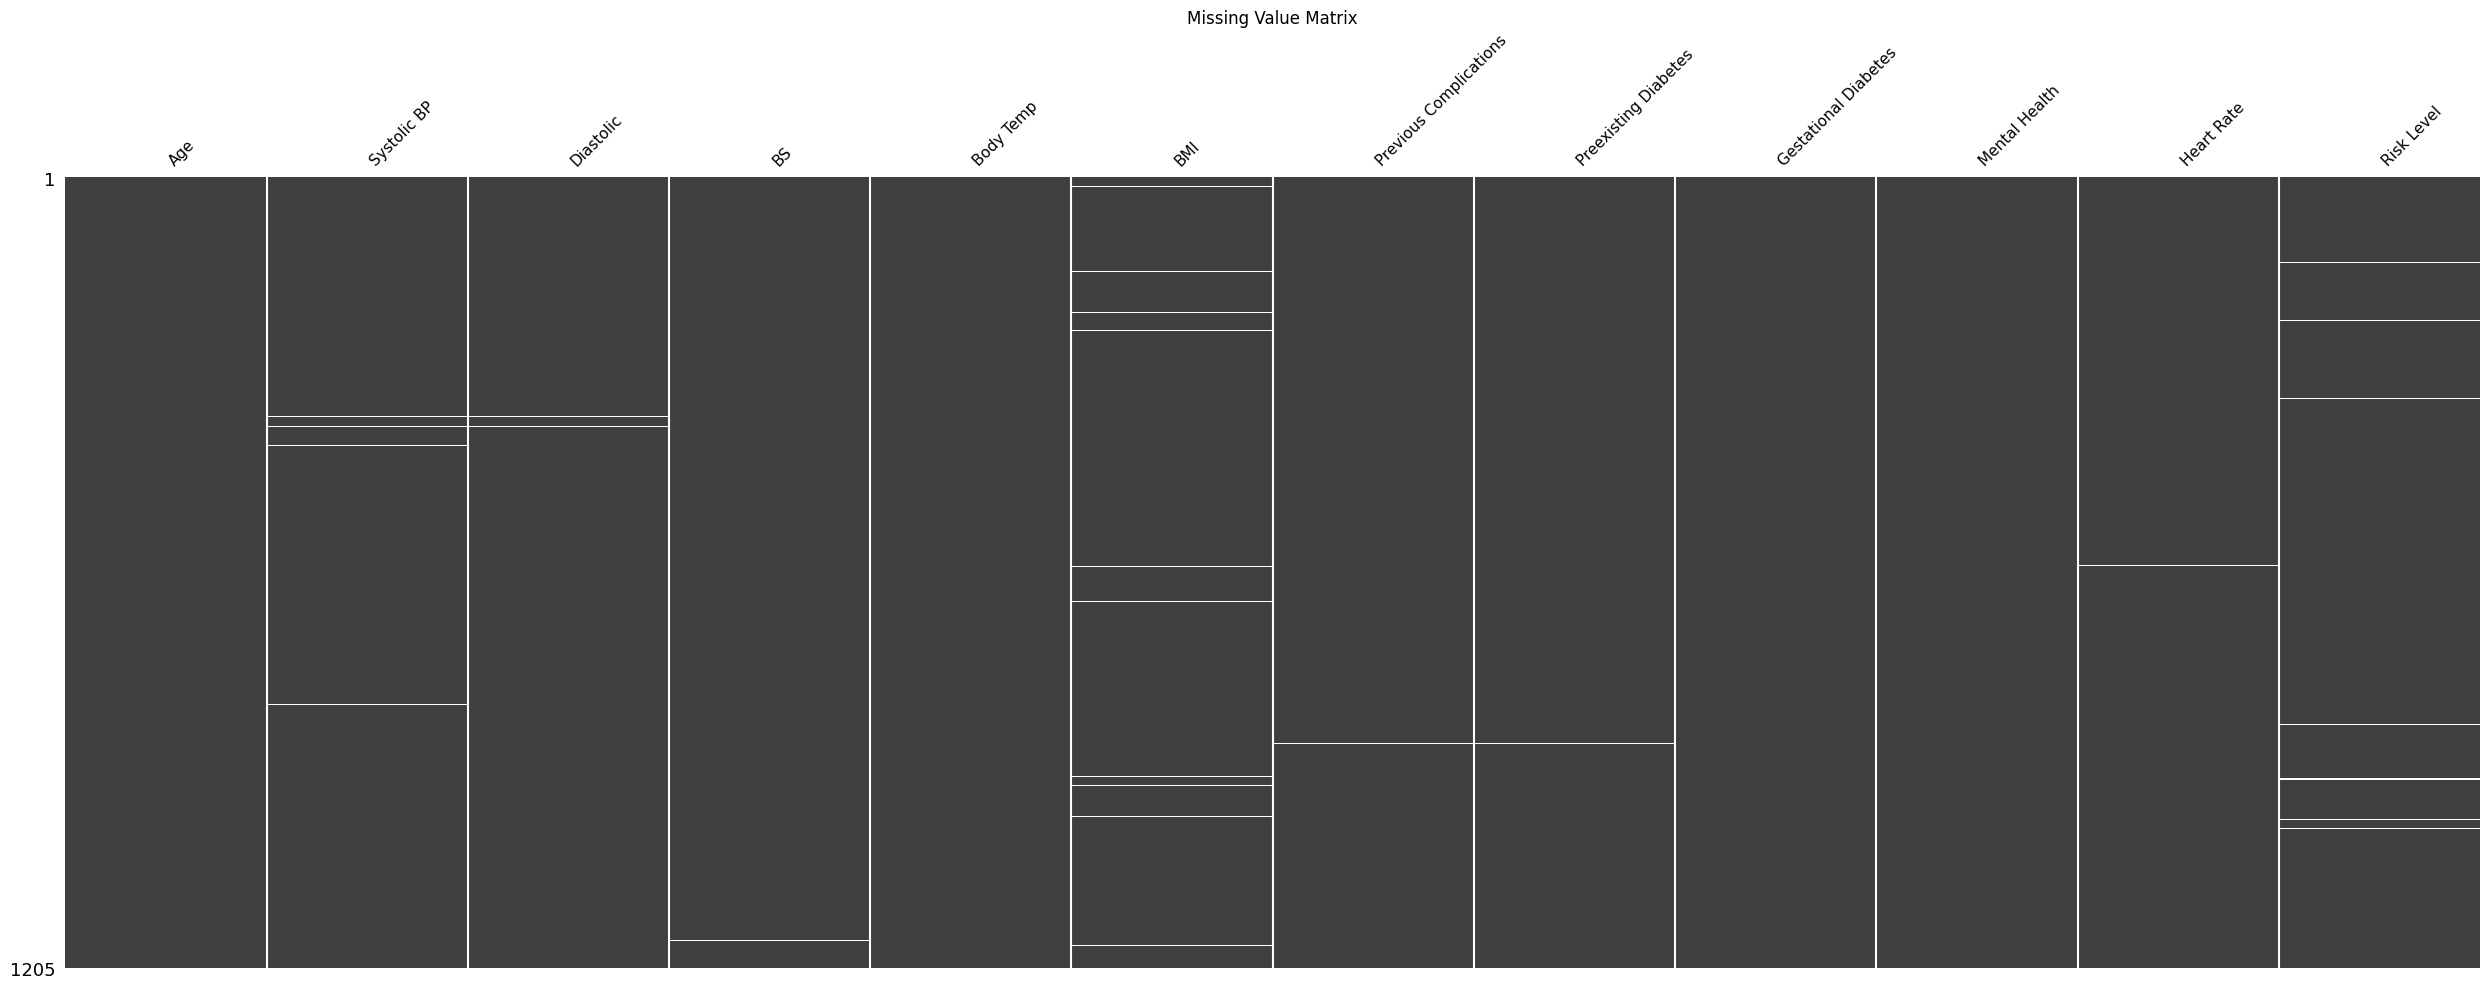

In [41]:
import missingno as msno
import matplotlib.pyplot as plt

# Missing value matrix
plt.figure()
msno.matrix(df, sparkline=False, fontsize=11)
plt.title("Missing Value Matrix")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

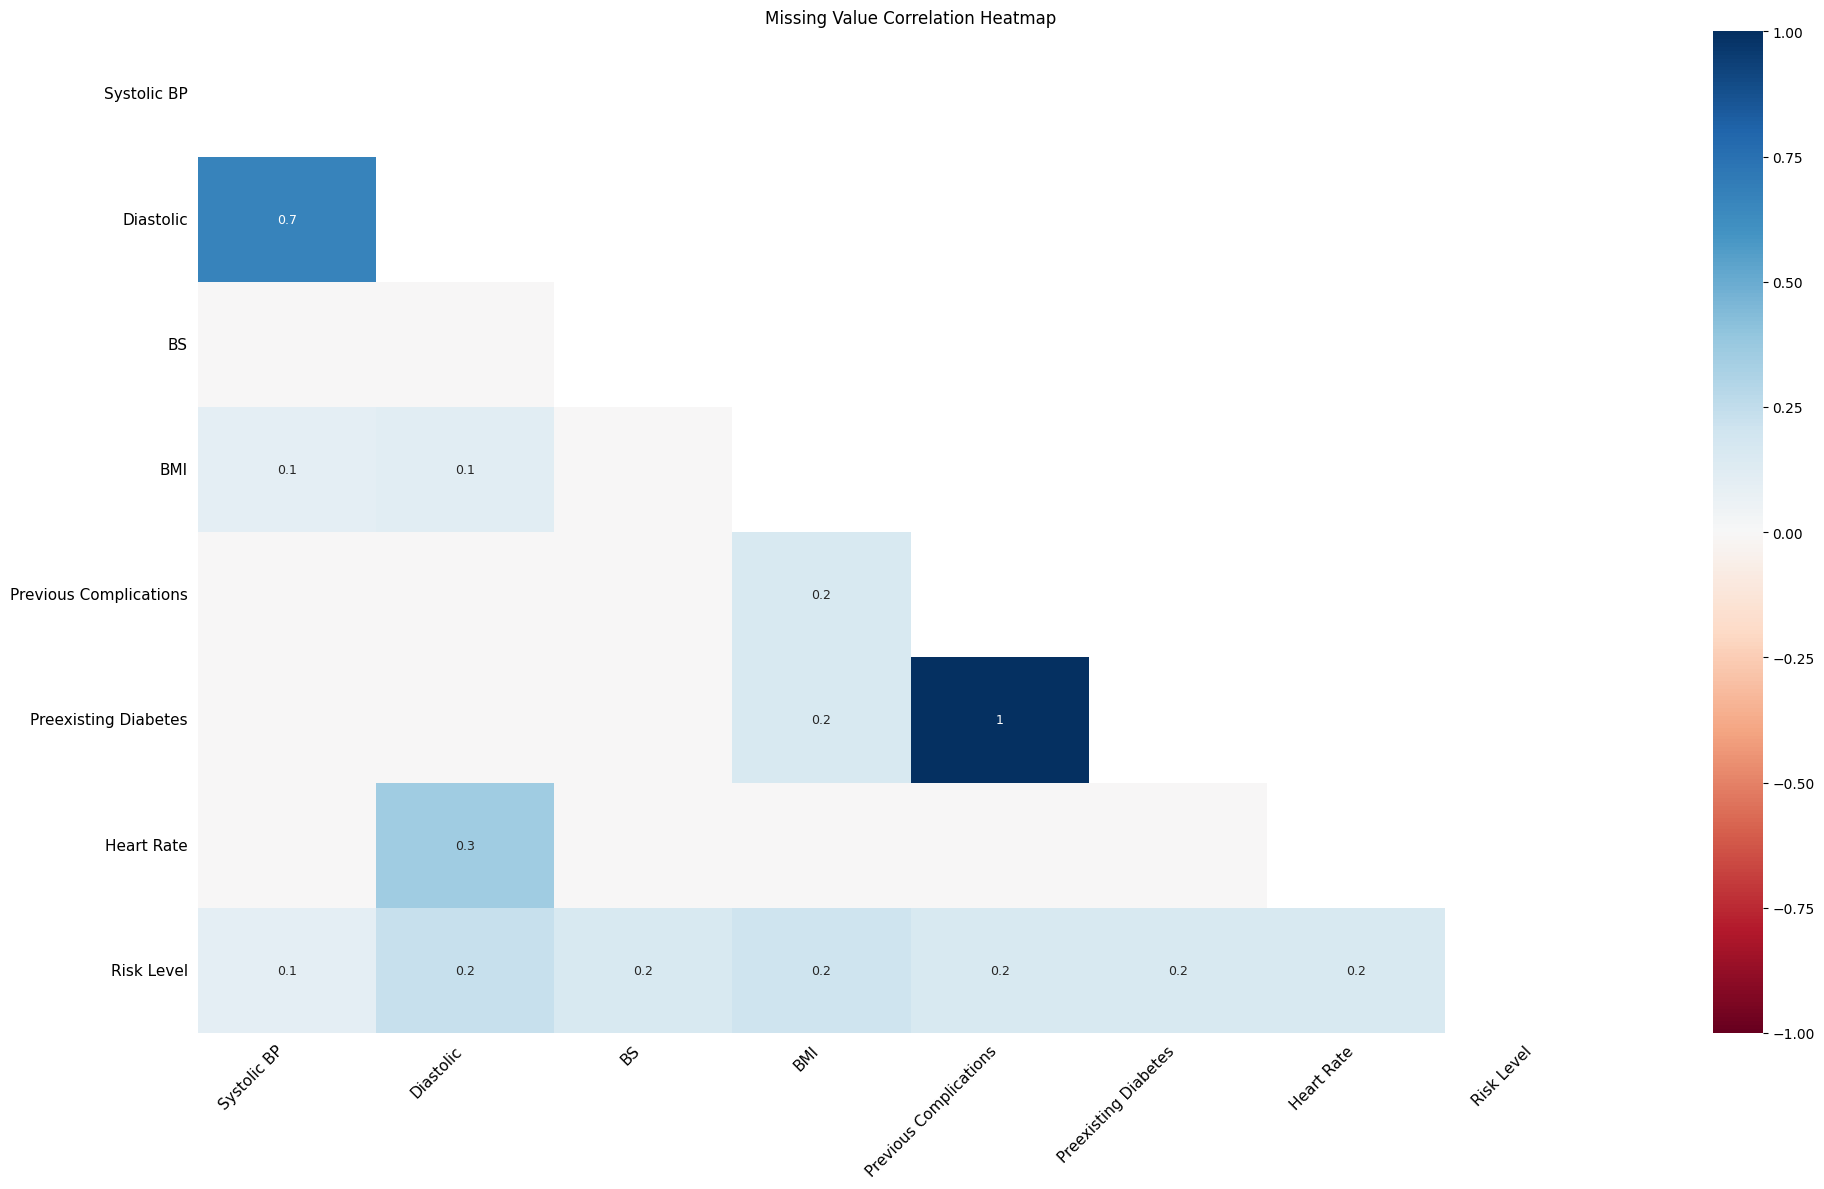

In [42]:
# Missing value correlation heatmap
plt.figure()
msno.heatmap(df, fontsize=11)
plt.title("Missing Value Correlation Heatmap")
plt.tight_layout()
plt.show()

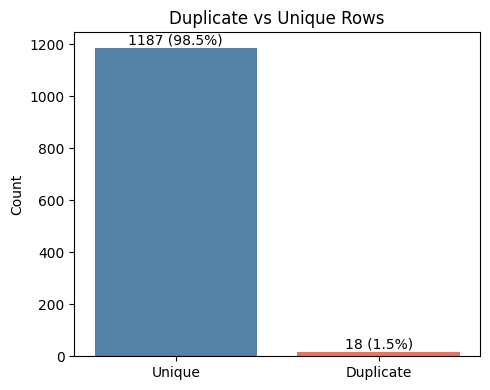

In [43]:
import seaborn as sns

dup_labels = df.duplicated().map({True: "Duplicate", False: "Unique"})

plt.figure(figsize=(5, 4))
ax = sns.countplot(x=dup_labels, palette=["steelblue", "tomato"])
plt.title("Duplicate vs Unique Rows")
plt.xlabel("")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

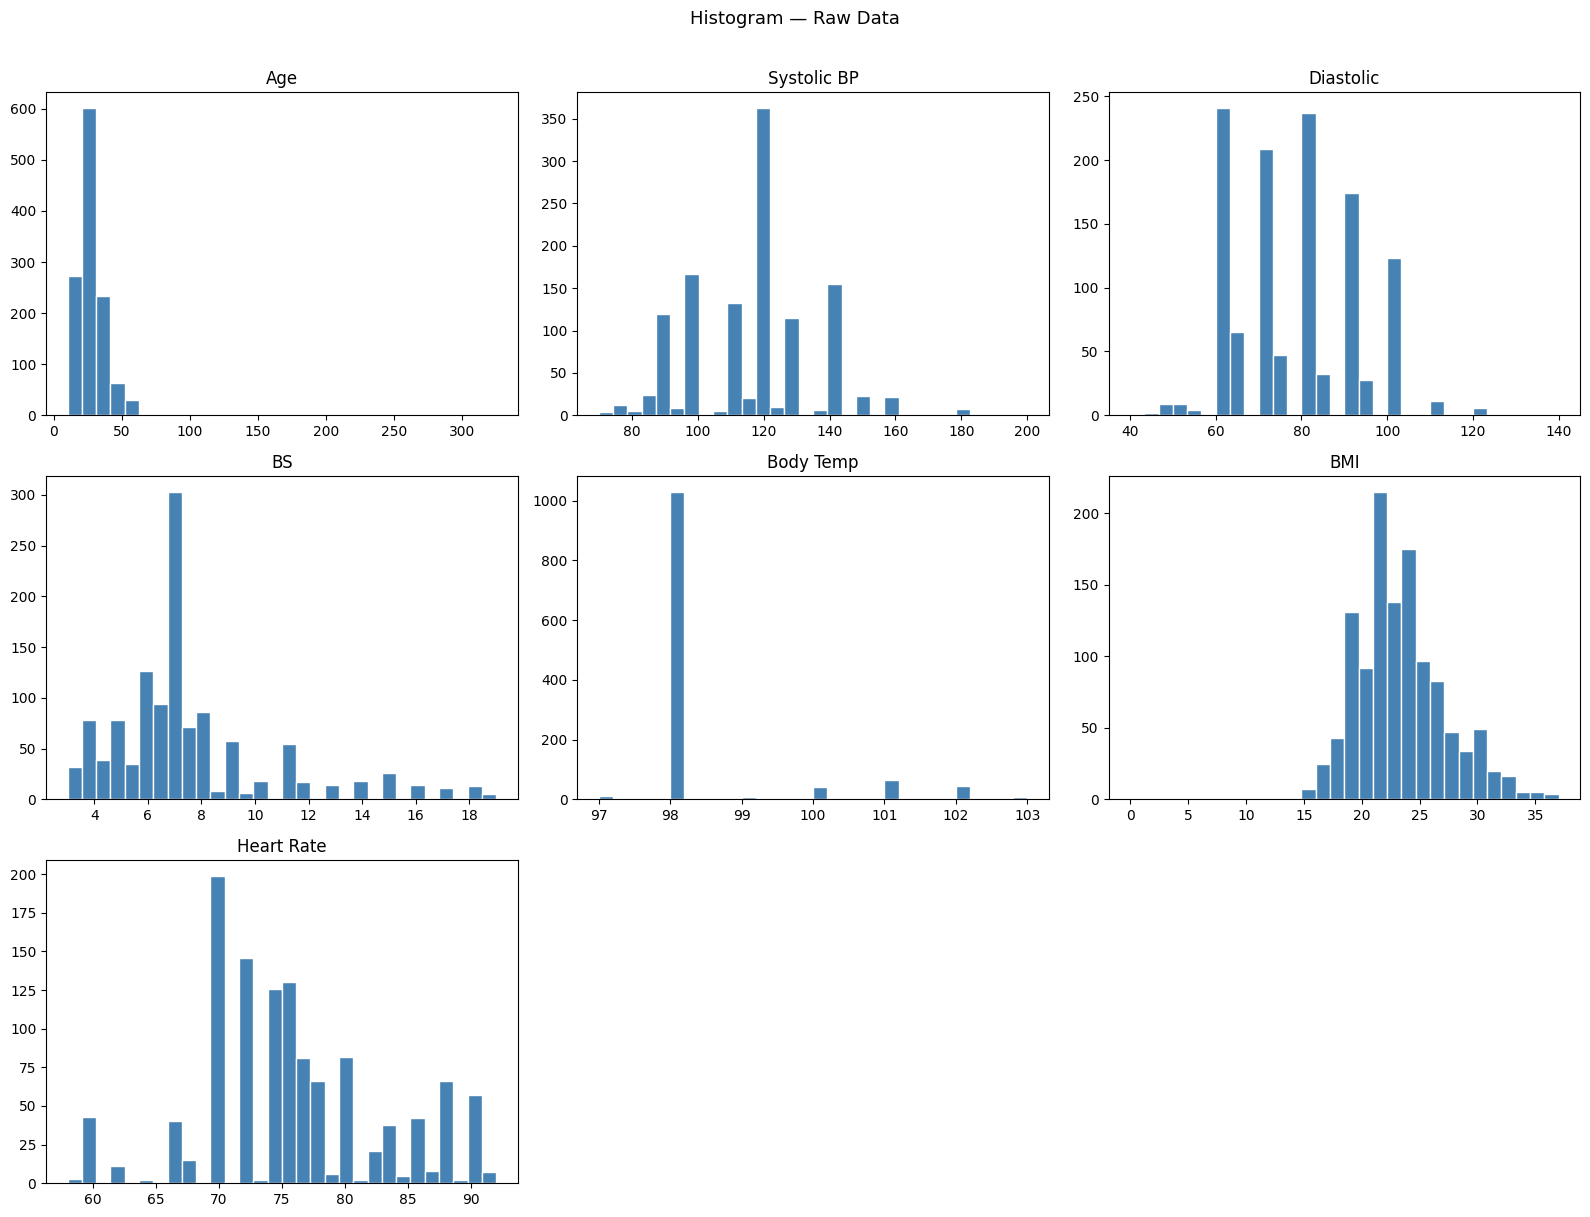

In [44]:


n = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogram — Raw Data", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

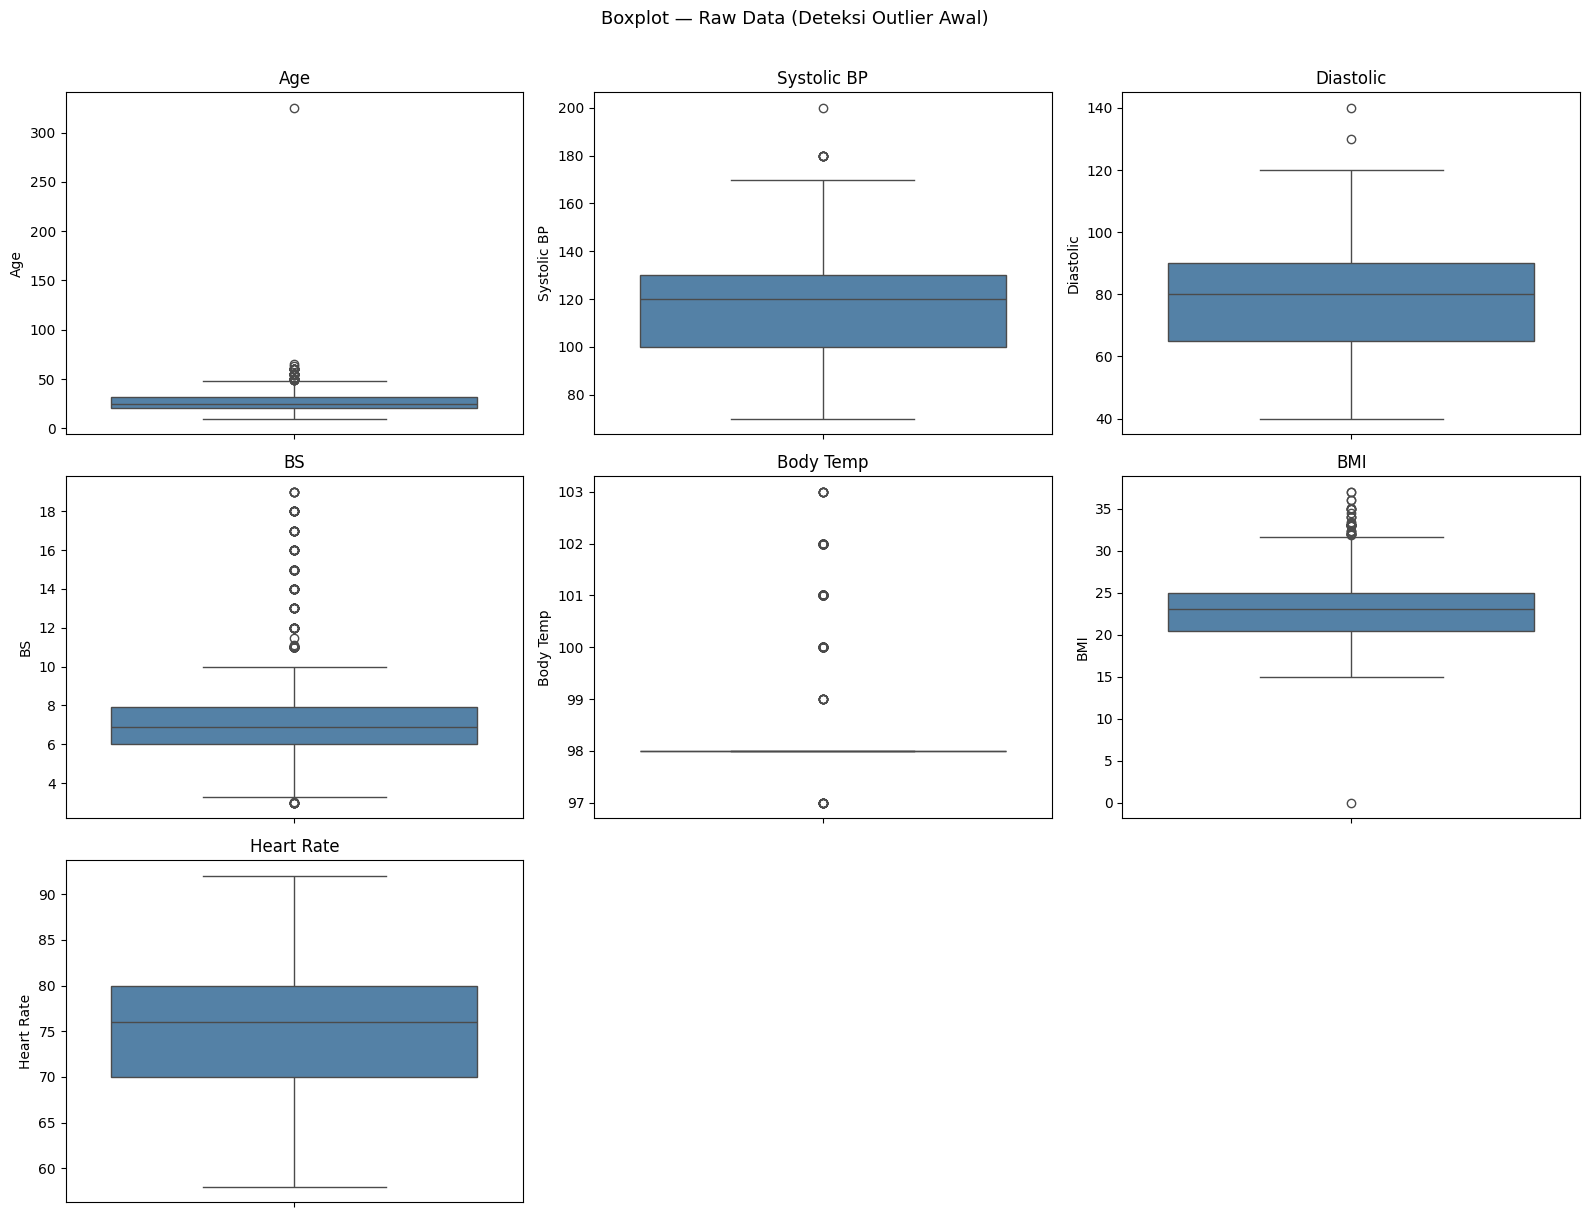

In [45]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="steelblue")
    axes[i].set_title(col)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot — Raw Data (Deteksi Outlier Awal)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [46]:
df_clean = df.copy()

# Drop duplicates
df_clean = df_clean.drop_duplicates()

# Drop rows dengan missing target
df_clean = df_clean.dropna(subset=["Risk Level"])

# Imputasi median untuk semua kolom numerik
for col in df_clean.select_dtypes(include=[np.number]).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(f"Shape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}")
print(f"Rows dropped: {df.shape[0] - df_clean.shape[0]}")

Shape before: (1205, 12)
Shape after:  (1169, 12)
Rows dropped: 36


In [47]:
print("=" * 50)
print("NULL VALUES AFTER CLEANING")
null_after = df_clean.isnull().sum()
print(null_after[null_after > 0] if null_after.sum() > 0 else "✅ No null values")

print("\n" + "=" * 50)
print("DUPLICATES AFTER CLEANING")
print(f"Total duplicate rows: {df_clean.duplicated().sum()}")

print("\n" + "=" * 50)
print("TARGET DISTRIBUTION AFTER CLEANING")
target_counts = df_clean["Risk Level"].value_counts()
target_pct = df_clean["Risk Level"].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({"Count": target_counts, "Percentage (%)": target_pct}))

NULL VALUES AFTER CLEANING
✅ No null values

DUPLICATES AFTER CLEANING
Total duplicate rows: 1

TARGET DISTRIBUTION AFTER CLEANING
            Count  Percentage (%)
Risk Level                       
Low           696           59.54
High          473           40.46


In [48]:
# ── Domain-Based Capping (Clinical Threshold Winsorization) ──
# Each bound is backed by peer-reviewed clinical guidelines.
#
# REFERENCES:
# [1] WHO. Diagnostic Criteria and Classification of Hyperglycaemia
#     First Detected in Pregnancy. Geneva: WHO; 2013.
#     https://www.ncbi.nlm.nih.gov/books/NBK169023/
#
# [2] ACOG Practice Bulletin No. 222: Gestational Hypertension and
#     Preeclampsia. Obstet Gynecol. 2020;135(6):e237-e260.
#     https://doi.org/10.1097/AOG.0000000000003891
#
# [3] ACOG Committee Opinion No. 692: Emergent Therapy for
#     Acute-Onset, Severe Hypertension During Pregnancy and the
#     Postpartum Period. Obstet Gynecol. 2017;129:e90-e95.
#
# [4] ACOG Obstetric Care Consensus No. 11: Pregnancy at Age 35
#     Years or Older. Obstet Gynecol. 2022;140(2):348-366.
#     https://doi.org/10.1097/AOG.0000000000004906
#
# [5] WHO. BMI Classification. Global Database on Body Mass Index.
#     World Health Organization; 2004.
#
# [6] Monga M. Maternal cardiovascular and renal adaptation to
#     pregnancy. In: Creasy RK, Resnik R, eds. Maternal-Fetal
#     Medicine. 5th ed. Saunders; 2004.

clinical_bounds = {
    #  Age: lower = menarche biological minimum (ACOG OCC No. 11);
    #       upper = extreme upper boundary, natural conception after
    #       45 is unlikely; 50 used as clinical hard ceiling [4]
    "Age":         (12, 50),

    #  Systolic BP: lower = hypotensive threshold indicating
    #               hypovolemic shock (MAP collapse);
    #               upper = severe-range preeclampsia threshold
    #               per ACOG PB 222, treatment mandated at >=160;
    #               220 represents hypertensive crisis ceiling [2][3]
    "Systolic BP": (70, 220),

    #  Diastolic: lower = vascular collapse threshold;
    #             upper = severe preeclampsia per ACOG PB 222
    #             defined as DBP >= 110; 130 represents
    #             hypertensive emergency ceiling [2][3]
    "Diastolic":   (40, 130),

    #  BS (Blood Sugar, mmol/L):
    #     lower = ADA Level 2 severe hypoglycemia threshold (<3.0)
    #             requiring immediate intervention;
    #     upper = DKA-range hyperglycemia. WHO 2013 criteria define
    #             overt diabetes in pregnancy at fasting >= 7.0,
    #             random >= 11.1; 25.0 represents extreme DKA-level
    #             upper physiological boundary [1]
    "Blood Sugar": (3.0, 25.0),

    #  Body Temp (Fahrenheit):
    #     lower = 95°F (35°C) = clinical hypothermia threshold
    #             (WHO/clinical consensus);
    #     upper = 105°F (40.6°C) = hyperpyrexia range, above which
    #             maternal and fetal neurological damage risk is
    #             severe; clinical threshold per obstetric textbooks
    "Body Temp":   (95, 105),

    #  BMI: lower = WHO Grade III thinness threshold (<16 kg/m2);
    #       14 represents extreme cachexia consistent with
    #       amenorrhea/infertility boundary;
    #       upper = 65 represents extreme morbid obesity; WHO
    #       Class III obesity defined as >= 40 kg/m2 [5]
    "BMI":         (14, 65),

    #  Heart Rate (bpm): lower = extreme bradycardia threshold
    #                    requiring intervention;
    #                    upper = SVT/extreme tachycardia boundary
    #                    in pregnancy; resting HR in pregnancy
    #                    increases 10-20 bpm above baseline [6]
    "Heart Rate":  (40, 200),
}

print("=" * 65)
print("DOMAIN-BASED CAPPING — Clinical Threshold Winsorization")
print("=" * 65)

capping_summary = []
df_clean.loc[:, col] = df_clean[col].clip(lower=lower, upper=upper)

for col, (lower, upper) in clinical_bounds.items():
    if col not in df_clean.columns:
        print(f"  Column '{col}' not found, skipped.")
        continue

    n_lower = (df_clean[col] < lower).sum()
    n_upper = (df_clean[col] > upper).sum()
    n_capped = n_lower + n_upper

    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    capping_summary.append({
        "Column"       : col,
        "Lower Bound"  : lower,
        "Upper Bound"  : upper,
        "Capped Low"   : n_lower,
        "Capped High"  : n_upper,
        "Total Capped" : n_capped,
    })

    status = "✅" if n_capped == 0 else f"⚠️  {n_capped} values capped"
    print(f"{col:<15} [{lower}, {upper}]  →  {status}")
    if n_capped > 0:
        print(f"               low: {n_lower} capped to {lower}  |  "
              f"high: {n_upper} capped to {upper}")

print("=" * 65)
print(f"Total values capped : {sum(r['Total Capped'] for r in capping_summary)}")
print(f"Rows preserved      : {len(df_clean)} (no rows dropped)")
print("=" * 65)

summary_df = pd.DataFrame(capping_summary).set_index("Column")
display(summary_df)

# assign capped_columns for before/after visualization
capped_columns = [r["Column"] for r in capping_summary if r["Total Capped"] > 0]
print(f"\nColumns with capping applied: {capped_columns}")

DOMAIN-BASED CAPPING — Clinical Threshold Winsorization
Age             [12, 50]  →  ⚠️  34 values capped
               low: 1 capped to 12  |  high: 33 capped to 50
Systolic BP     [70, 220]  →  ✅
Diastolic       [40, 130]  →  ⚠️  1 values capped
               low: 0 capped to 40  |  high: 1 capped to 130
  Column 'Blood Sugar' not found, skipped.
Body Temp       [95, 105]  →  ✅
BMI             [14, 65]  →  ⚠️  1 values capped
               low: 1 capped to 14  |  high: 0 capped to 65
Heart Rate      [40, 200]  →  ✅
Total values capped : 36
Rows preserved      : 1169 (no rows dropped)


,Lower Bound,Upper Bound,Capped Low,Capped High,Total Capped
Column,,,,,
Age,12,50,1,33,34
Systolic BP,70,220,0,0,0
Diastolic,40,130,0,1,1
Body Temp,95,105,0,0,0
BMI,14,65,1,0,1
Heart Rate,40,200,0,0,0



Columns with capping applied: ['Age', 'Diastolic', 'BMI']


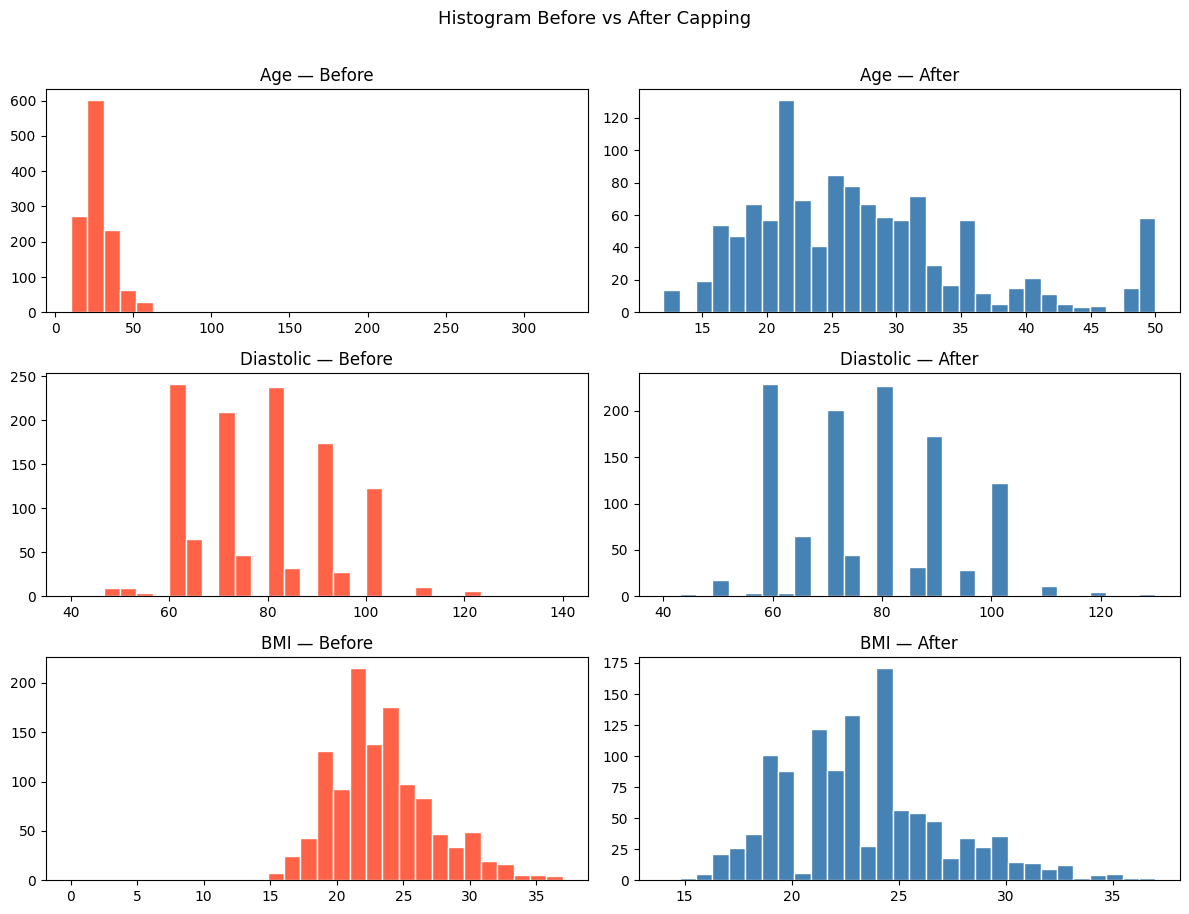

In [49]:
fig, axes = plt.subplots(len(capped_columns), 2, figsize=(12, len(capped_columns) * 3))

for i, col in enumerate(capped_columns):
    axes[i][0].hist(df[col].dropna(), bins=30, color="tomato", edgecolor="white")
    axes[i][0].set_title(f"{col} — Before")

    axes[i][1].hist(df_clean[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i][1].set_title(f"{col} — After")

plt.suptitle("Histogram Before vs After Capping", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

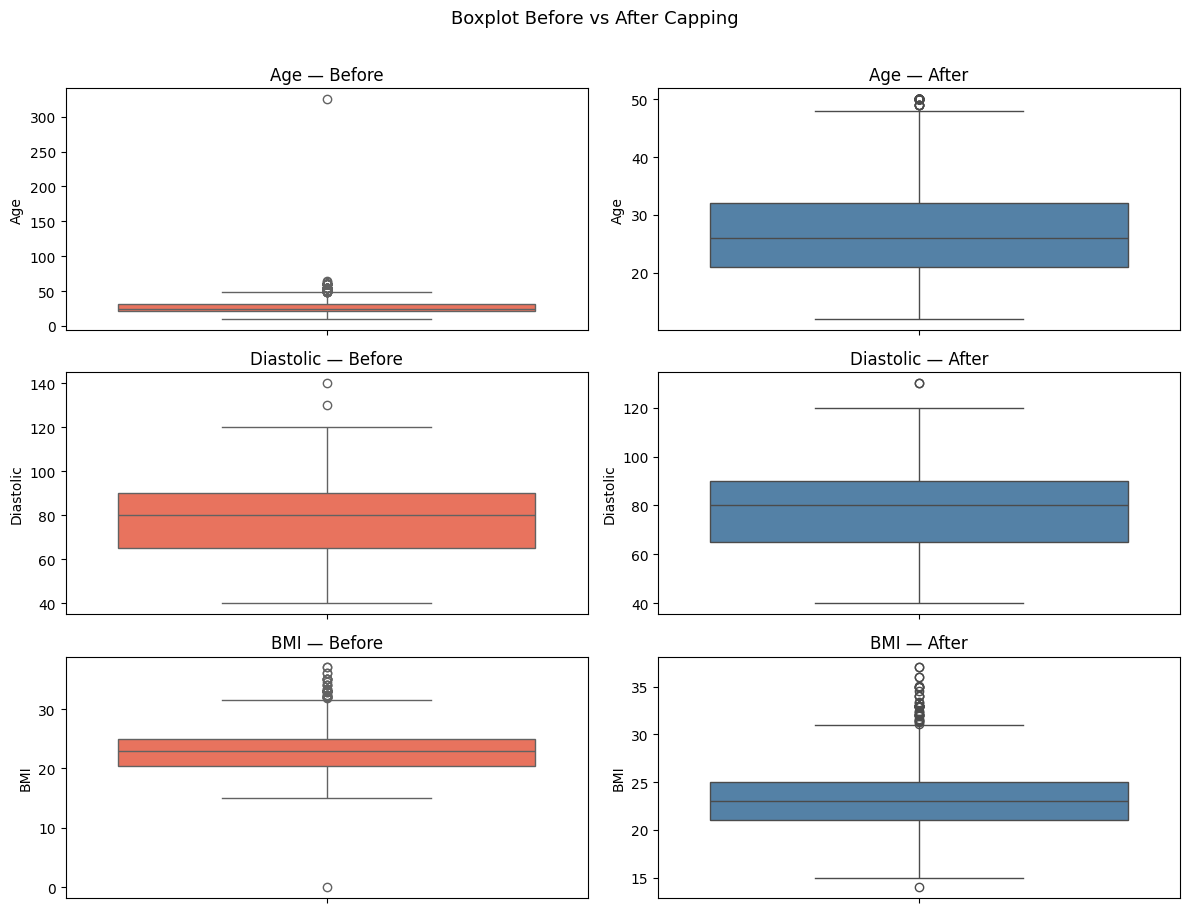

In [50]:
fig, axes = plt.subplots(len(capped_columns), 2, figsize=(12, len(capped_columns) * 3))

for i, col in enumerate(capped_columns):
    sns.boxplot(y=df[col], ax=axes[i][0], color="tomato")
    axes[i][0].set_title(f"{col} — Before")

    sns.boxplot(y=df_clean[col], ax=axes[i][1], color="steelblue")
    axes[i][1].set_title(f"{col} — After")

plt.suptitle("Boxplot Before vs After Capping", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

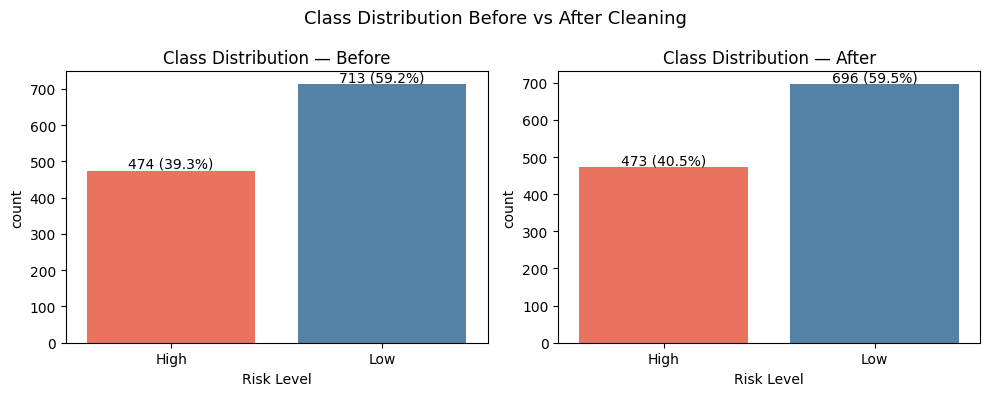

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x="Risk Level", data=df, ax=axes[0],
              order=["High", "Low"], palette=["tomato", "steelblue"])
axes[0].set_title("Class Distribution — Before")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

sns.countplot(x="Risk Level", data=df_clean, ax=axes[1],
              order=["High", "Low"], palette=["tomato", "steelblue"])
axes[1].set_title("Class Distribution — After")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())} ({p.get_height()/len(df_clean)*100:.1f}%)',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.suptitle("Class Distribution Before vs After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

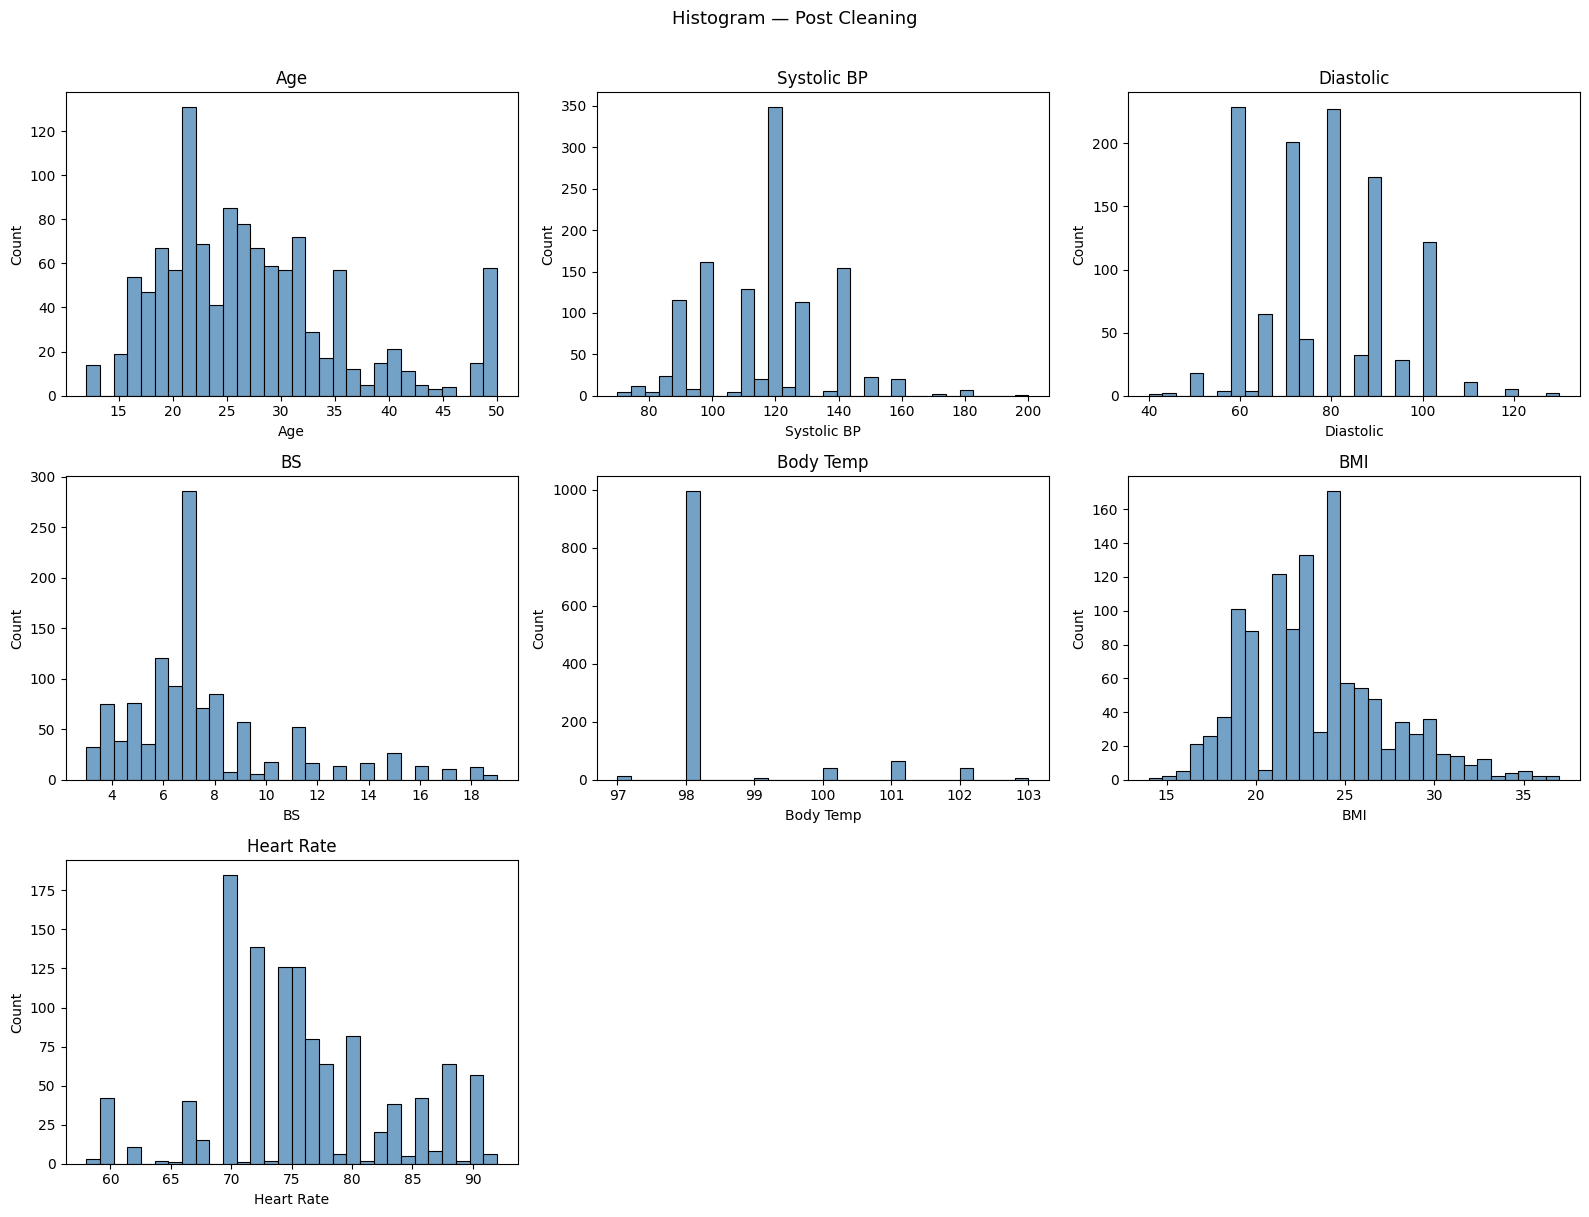

In [52]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_clean[col], bins=30, ax=axes[i], color="steelblue", kde=False)
    axes[i].set_title(col)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogram — Post Cleaning", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

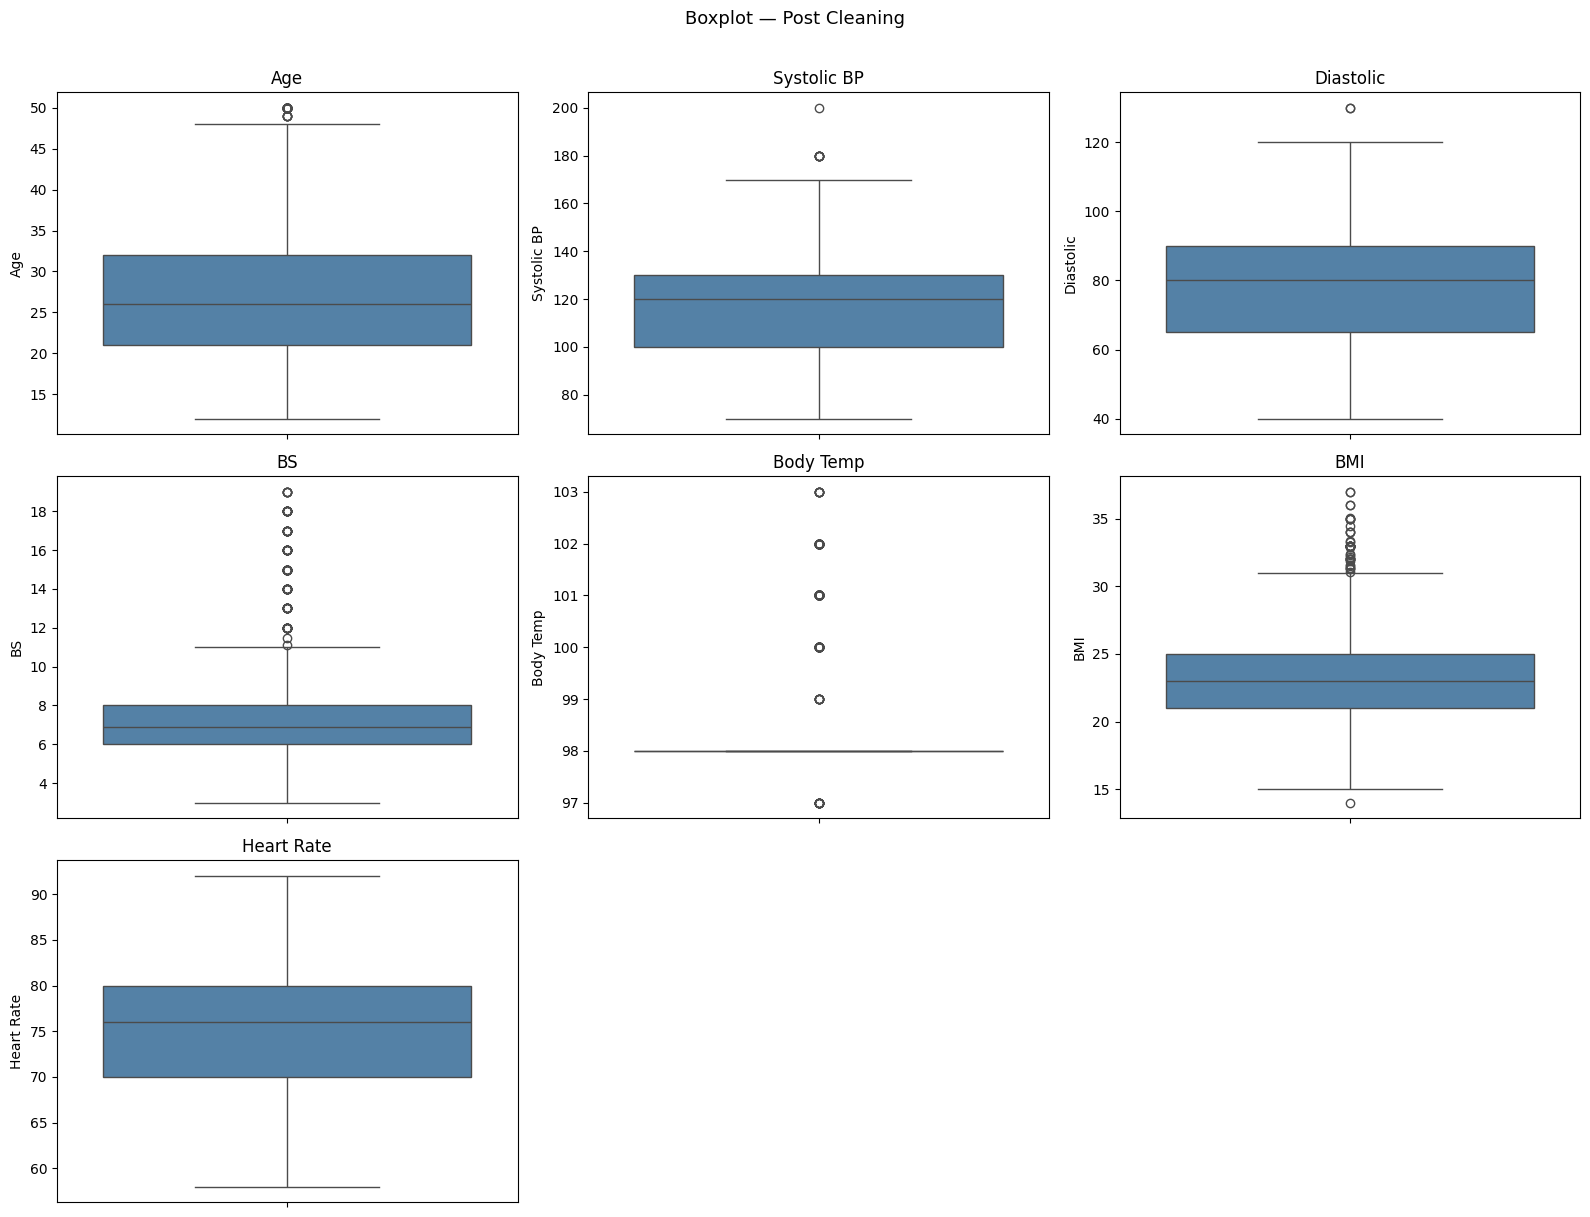

In [53]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color="steelblue")
    axes[i].set_title(col)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot — Post Cleaning", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

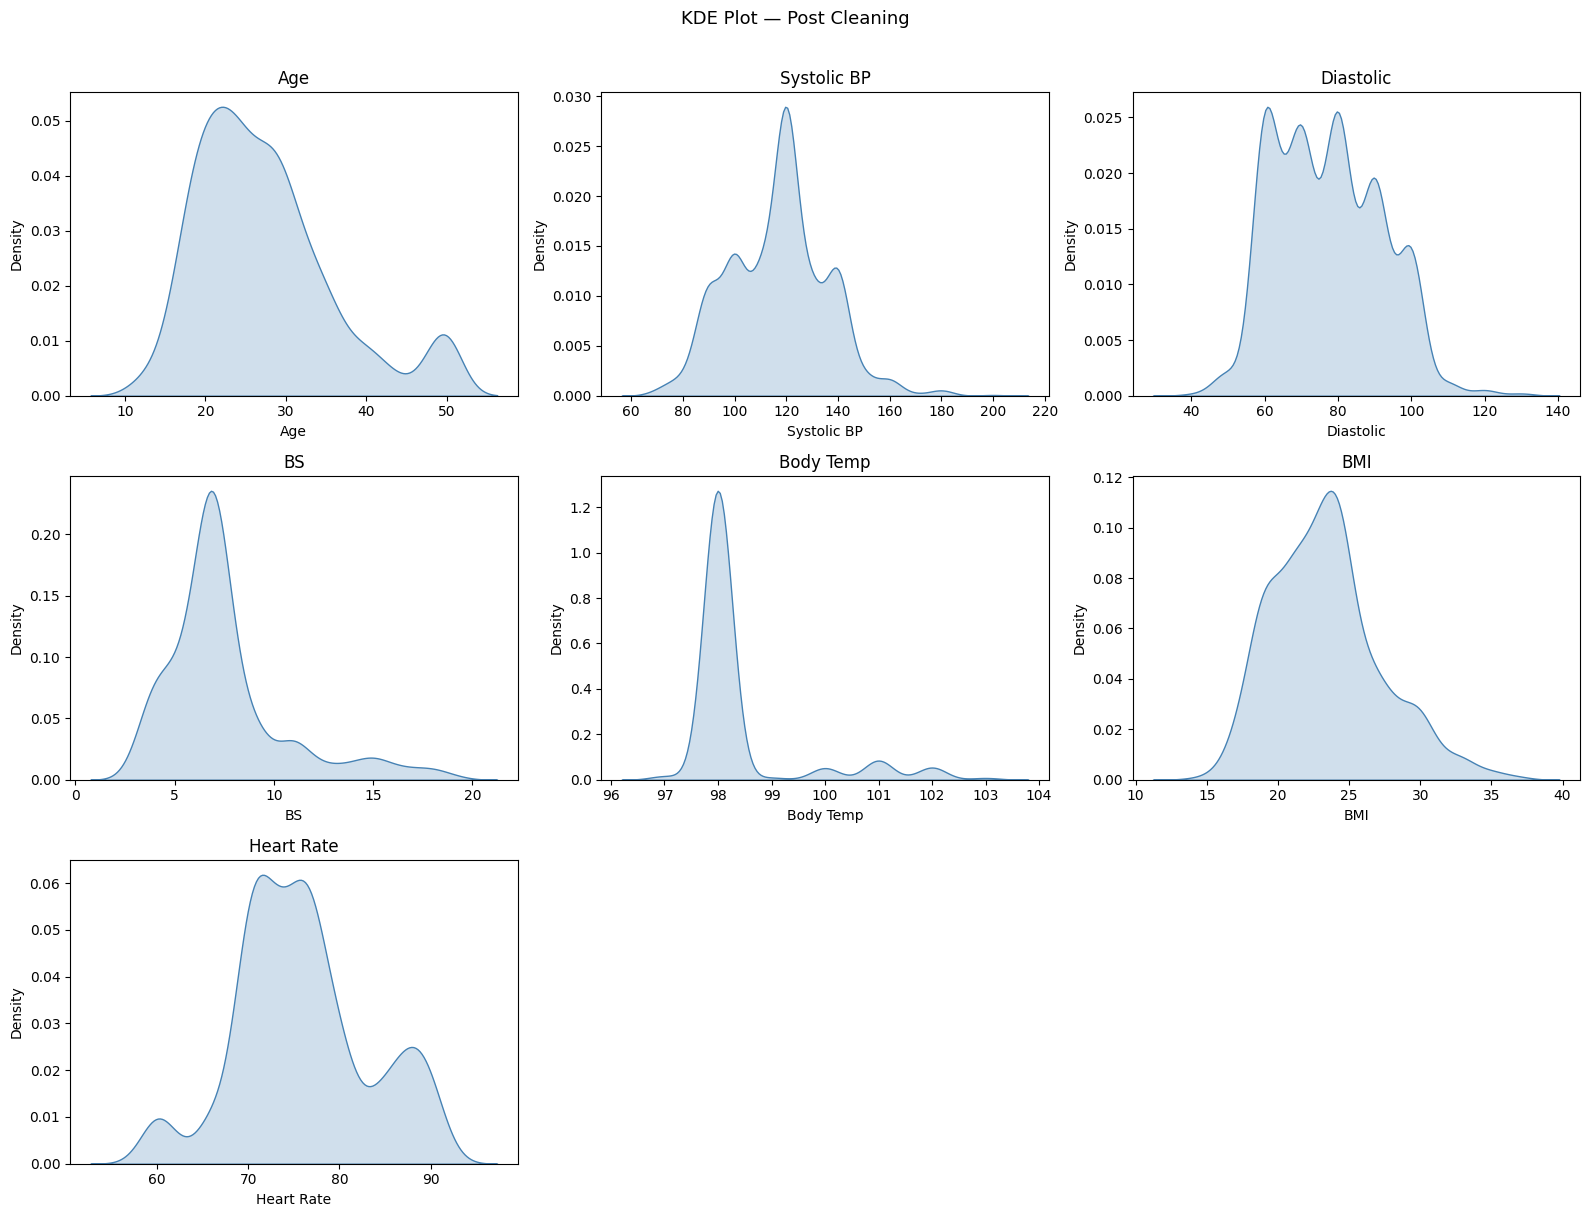

In [54]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(df_clean[col], ax=axes[i], fill=True, color="steelblue")
    axes[i].set_title(col)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("KDE Plot — Post Cleaning", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

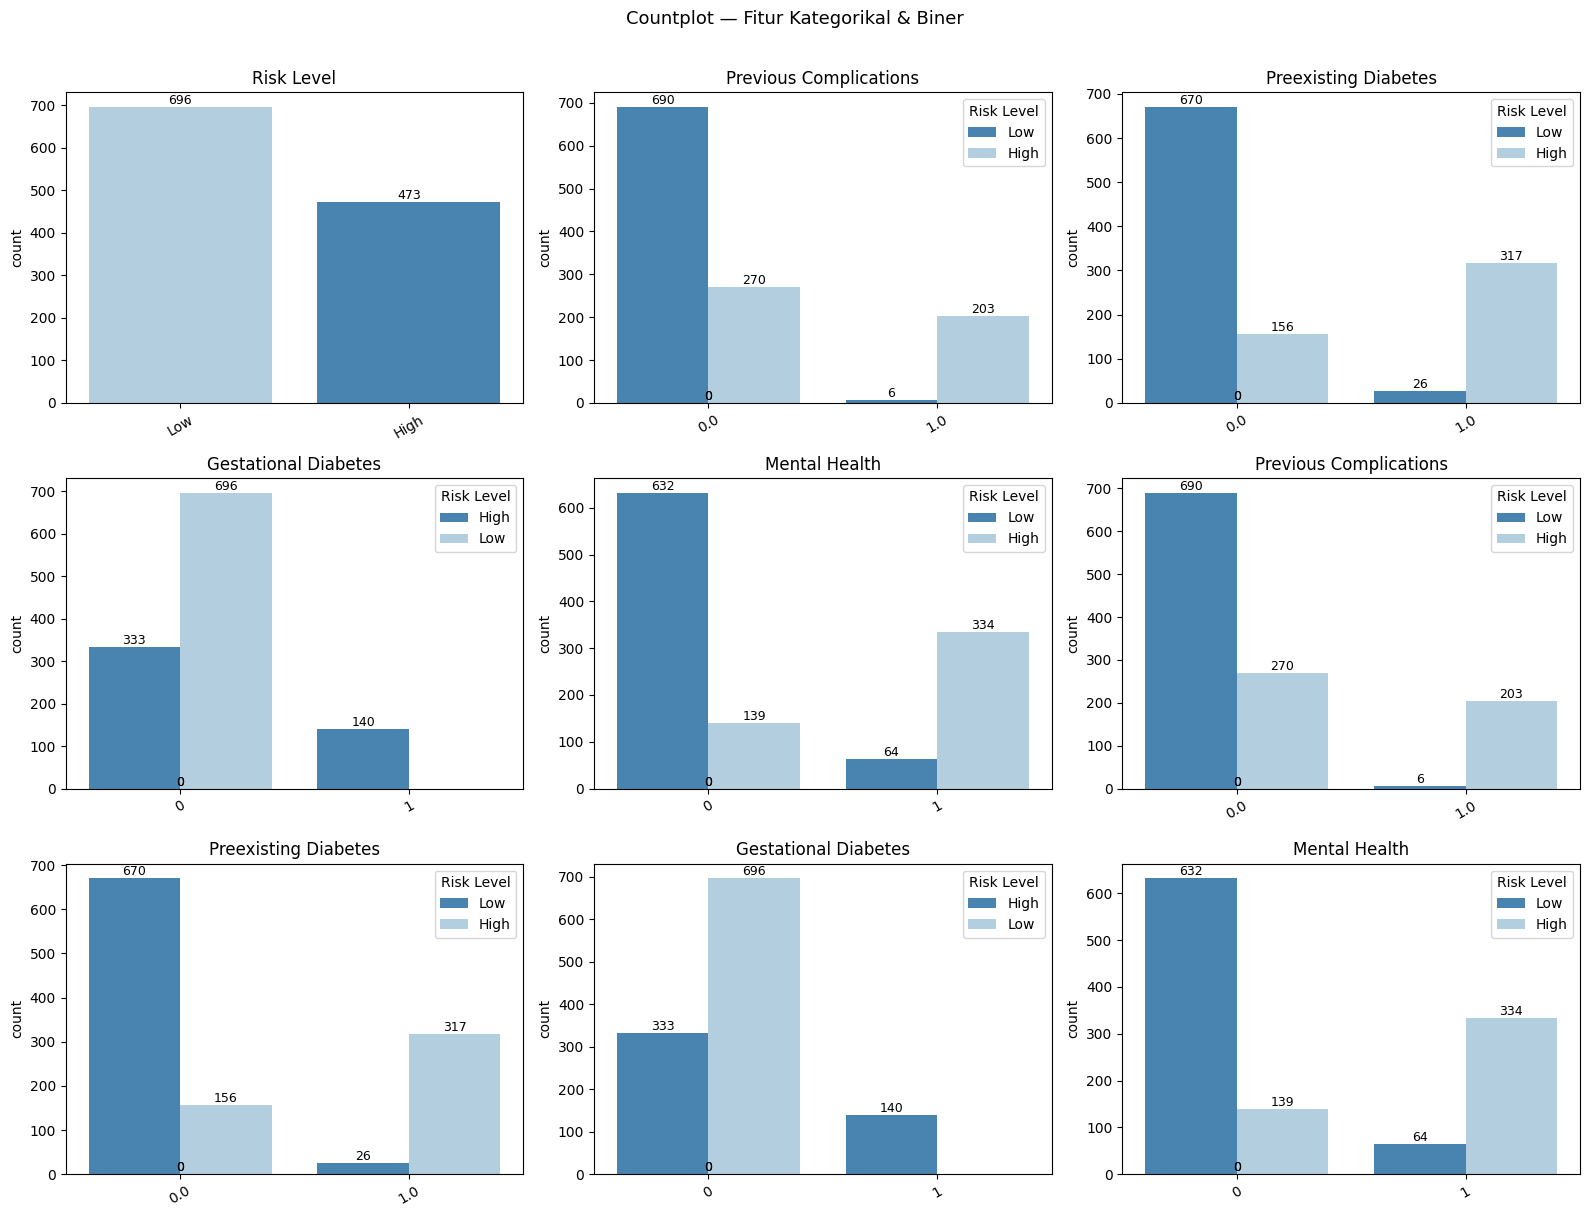

In [55]:


cat_all = cat_cols + binary_cols

n_cat = len(cat_all)
ncols_cat = 3
nrows_cat = (n_cat + ncols_cat - 1) // ncols_cat

fig, axes = plt.subplots(nrows_cat, ncols_cat, figsize=(16, nrows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cat_all):
    order = df_clean[col].value_counts().index
    sns.countplot(data=df_clean, x=col, ax=axes[i], order=order, hue="Risk Level", palette="Blues_r")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=9
        )

for j in range(n_cat, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Countplot — Fitur Kategorikal & Biner", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

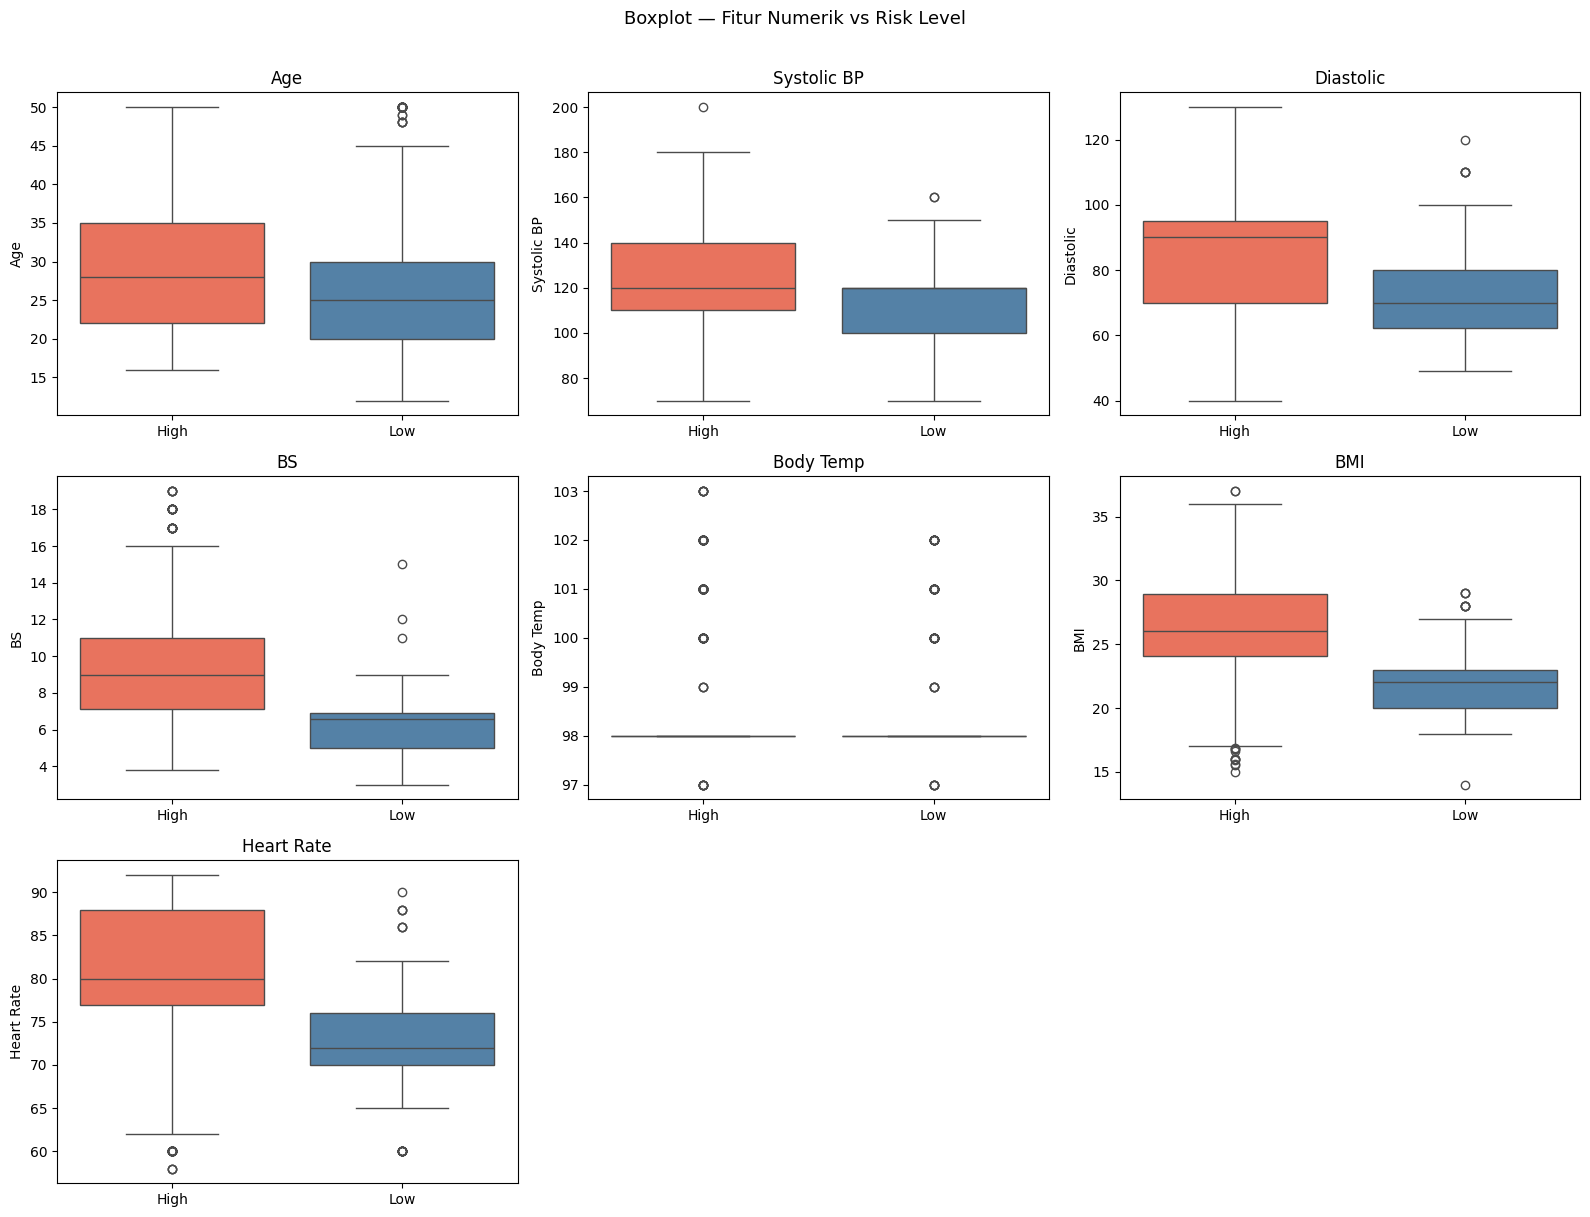

In [56]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_clean, x="Risk Level", y=col, ax=axes[i],
                order=["High", "Low"],
                hue = "Risk Level",
                palette={"High": "tomato", "Low": "steelblue"})
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplot — Fitur Numerik vs Risk Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

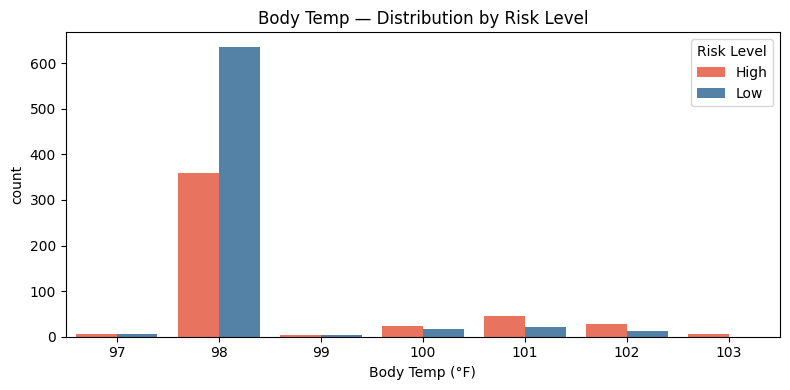

In [57]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x="Body Temp", hue="Risk Level",
              palette={"High": "tomato", "Low": "steelblue"})
plt.title("Body Temp — Distribution by Risk Level")
plt.xlabel("Body Temp (°F)")
plt.tight_layout()
plt.show()

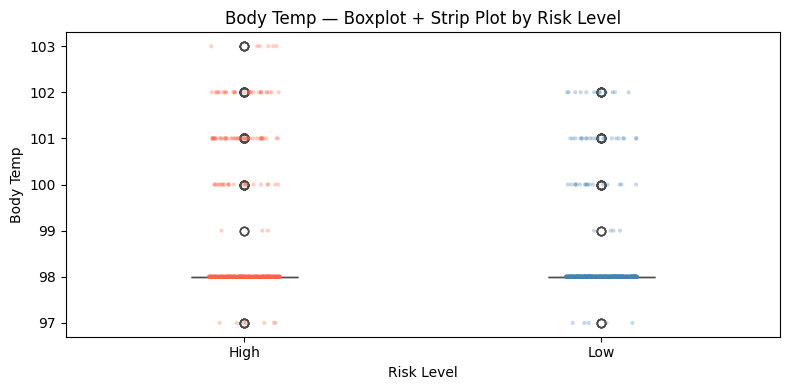

In [58]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="Risk Level", y="Body Temp",
            hue="Risk Level", legend=False,
            palette={"High": "tomato", "Low": "steelblue"},
            width=0.3)
sns.stripplot(data=df_clean, x="Risk Level", y="Body Temp",
              hue="Risk Level", legend=False,
              palette={"High": "tomato", "Low": "steelblue"},
              alpha=0.3, jitter=True, size=3)
plt.title("Body Temp — Boxplot + Strip Plot by Risk Level")
plt.tight_layout()
plt.show()

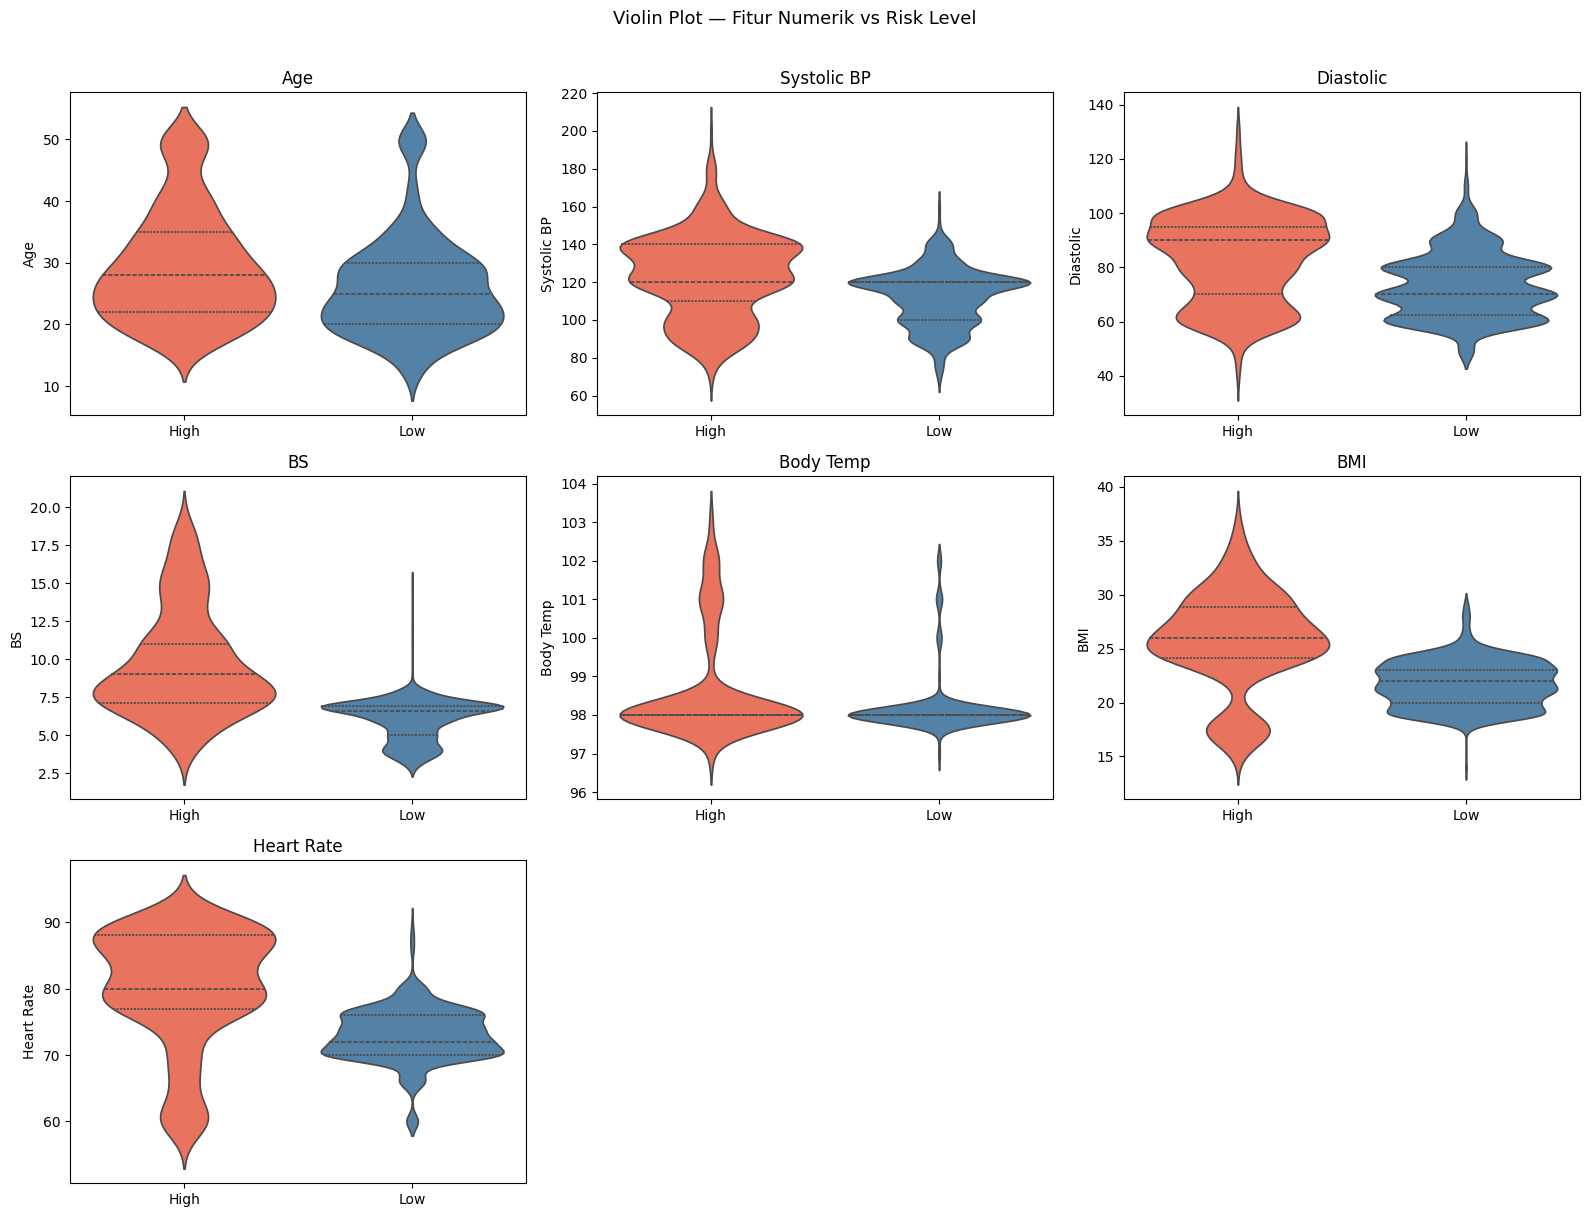

In [59]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.violinplot(data=df_clean, x="Risk Level", y=col, ax=axes[i],
                   order=["High", "Low"], inner="quartile",
                   palette={"High": "tomato", "Low": "steelblue"})
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Violin Plot — Fitur Numerik vs Risk Level", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [60]:
from scipy.stats import chi2_contingency

cat_cols = ["Previous Complications", "Preexisting Diabetes",
            "Gestational Diabetes", "Mental Health"]

print("Chi-Square Test — Fitur Kategorikal vs Risk Level")
print("=" * 55)

for col in cat_cols:
    ct = pd.crosstab(df_clean[col], df_clean["Risk Level"])
    chi2, p, dof, _ = chi2_contingency(ct)
    significance = "✅ Significant" if p < 0.05 else "❌ Not significant"
    print(f"{col:<25} p-value: {p}  {significance}")

Chi-Square Test — Fitur Kategorikal vs Risk Level
Previous Complications    p-value: 3.9080910072813363e-75  ✅ Significant
Preexisting Diabetes      p-value: 1.1768195607219369e-119  ✅ Significant
Gestational Diabetes      p-value: 3.2100301113722167e-52  ✅ Significant
Mental Health             p-value: 2.6906998762246295e-104  ✅ Significant


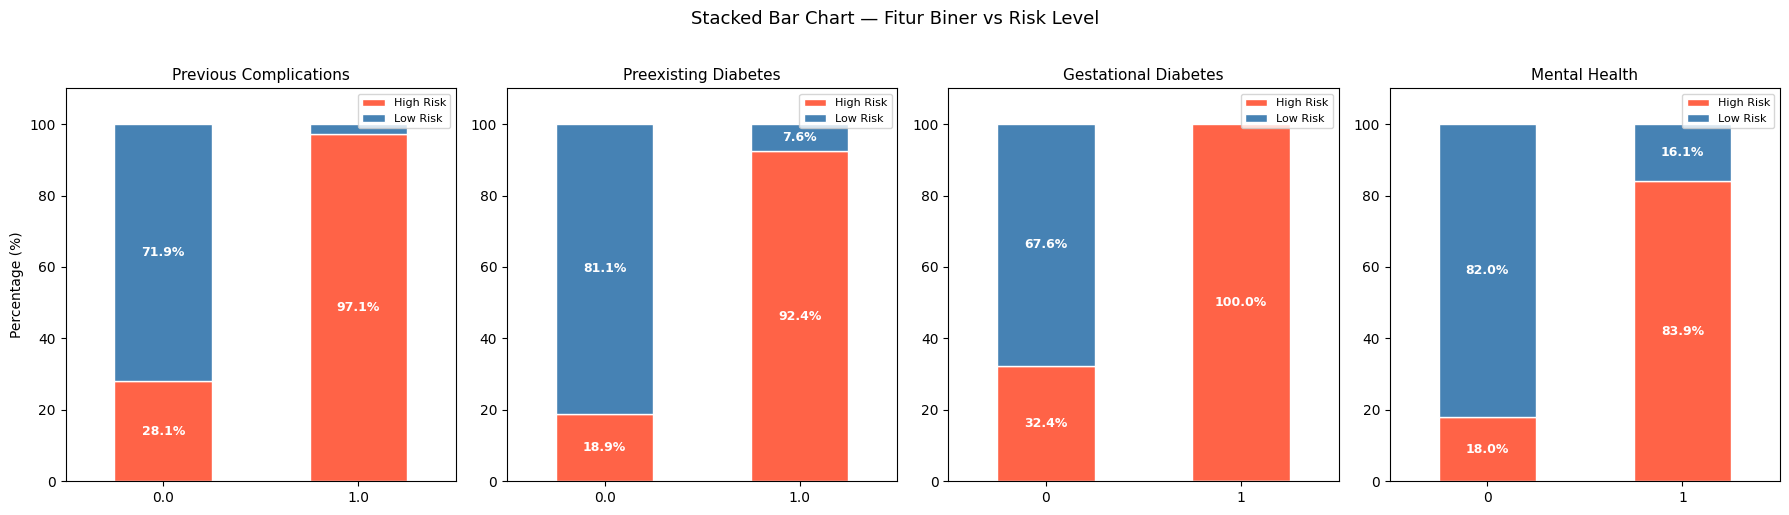

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean["Risk Level"], normalize="index") * 100

    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["tomato", "steelblue"], edgecolor="white", width=0.5)

    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)" if i == 0 else "")
    axes[i].set_ylim(0, 110)
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(["High Risk", "Low Risk"], fontsize=8, loc="upper right")

    # annotate tiap segment
    for bar in axes[i].patches:
        height = bar.get_height()
        if height > 3:  # skip label kalau segment terlalu kecil
            axes[i].annotate(
                f"{height:.1f}%",
                (bar.get_x() + bar.get_width() / 2,
                 bar.get_y() + height / 2),
                ha="center", va="center",
                fontsize=9, color="white", fontweight="bold"
            )

plt.suptitle("Stacked Bar Chart — Fitur Biner vs Risk Level", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

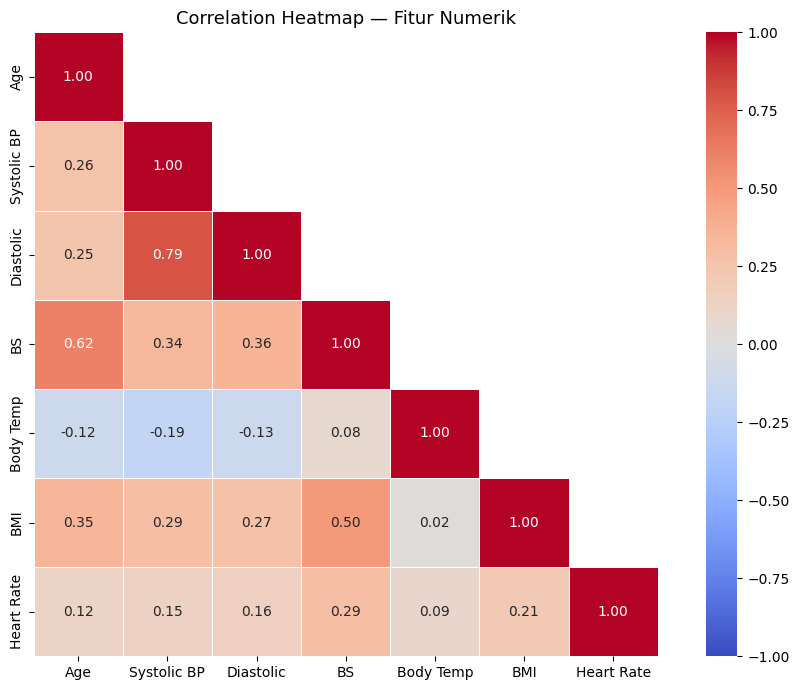

In [62]:
plt.figure(figsize=(10, 7))
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # k=1 biarkan diagonal tampil

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Fitur Numerik", fontsize=13)
plt.tight_layout()
plt.show()

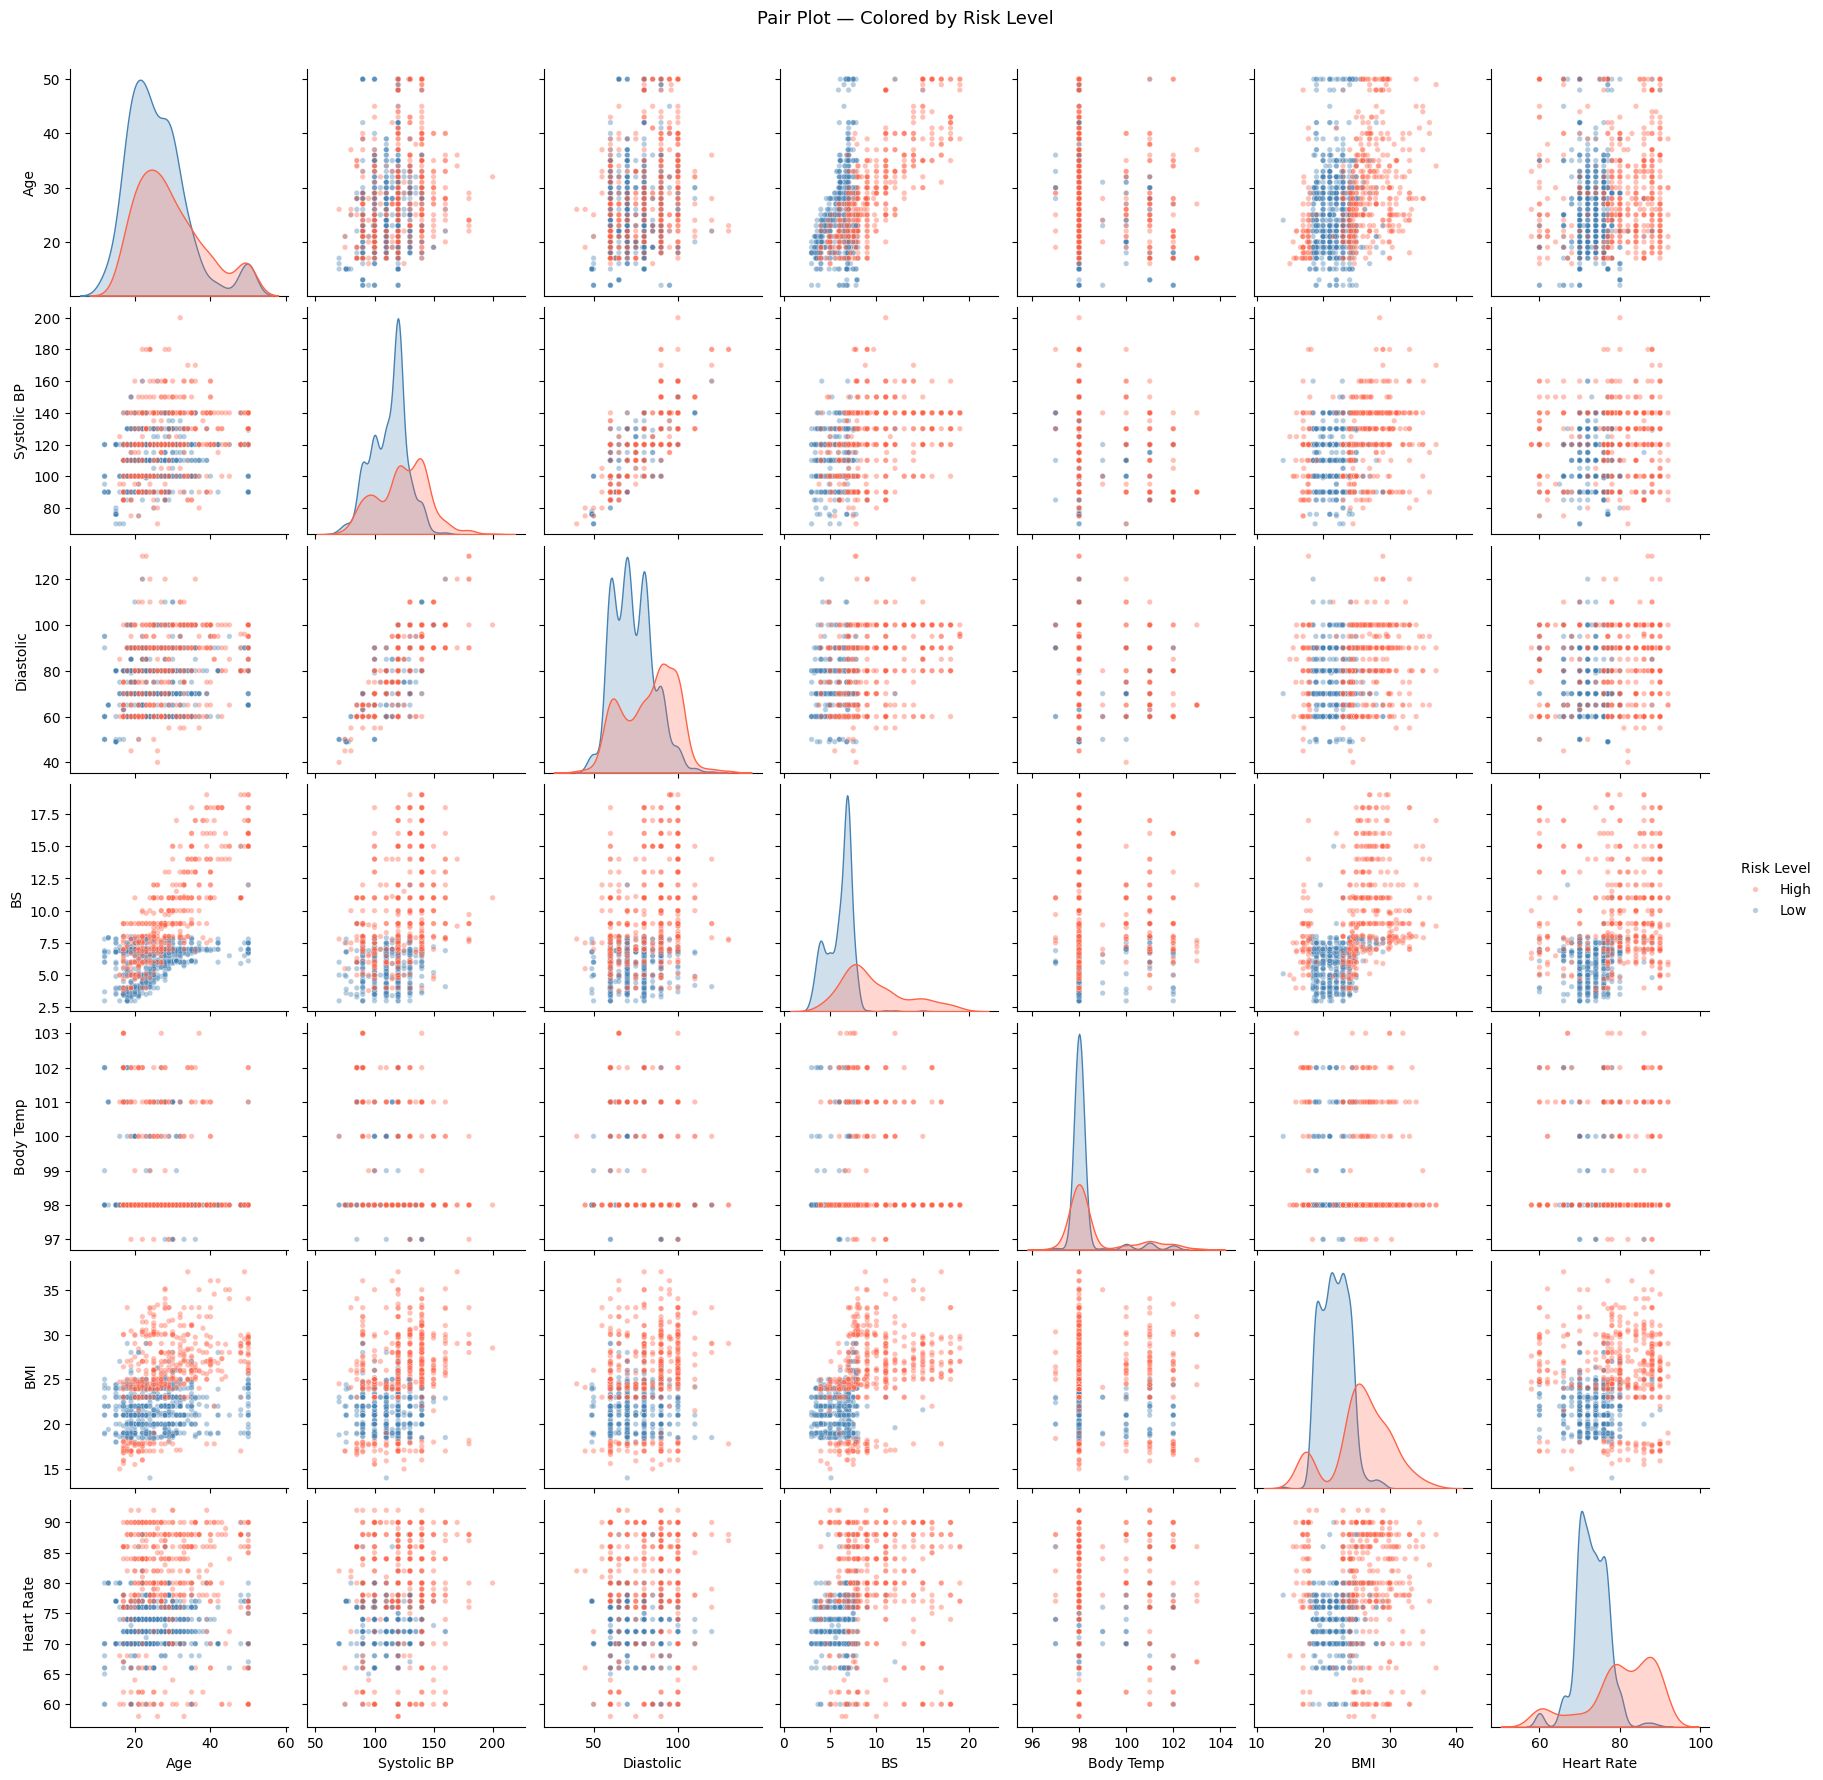

In [63]:
pair_cols = numeric_cols + ["Risk Level"]

sns.pairplot(df_clean[pair_cols], hue="Risk Level",
             palette={"High": "tomato", "Low": "steelblue"},
             plot_kws={"alpha": 0.4, "s": 15},
             diag_kind="kde")
plt.suptitle("Pair Plot — Colored by Risk Level", y=1.02, fontsize=13)
plt.show()

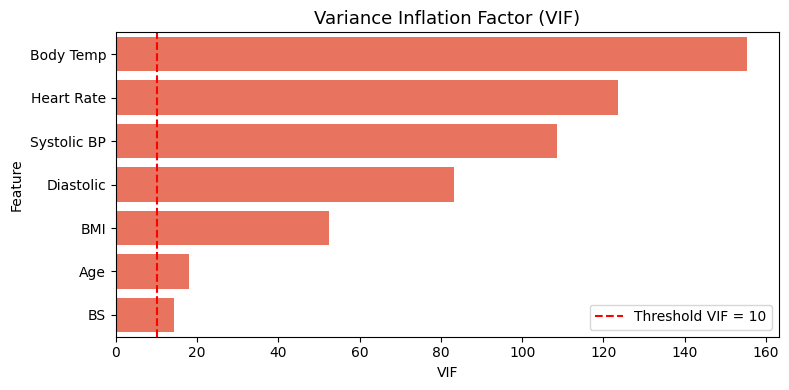

    Feature        VIF
  Body Temp 155.412126
 Heart Rate 123.518820
Systolic BP 108.492825
  Diastolic  83.133273
        BMI  52.343153
        Age  18.026211
         BS  14.201358


In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = df_clean[numeric_cols].dropna()

vif_df = pd.DataFrame({
    "Feature": numeric_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i)
            for i in range(len(numeric_cols))]
}).sort_values("VIF", ascending=False)

plt.figure(figsize=(8, 4))
colors = ["tomato" if v > 10 else "steelblue" for v in vif_df["VIF"]]
sns.barplot(data=vif_df, x="VIF", y="Feature", hue= "Feature", palette=colors)
plt.axvline(x=10, color="red", linestyle="--", label="Threshold VIF = 10")
plt.title("Variance Inflation Factor (VIF)", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(vif_df.to_string(index=False))

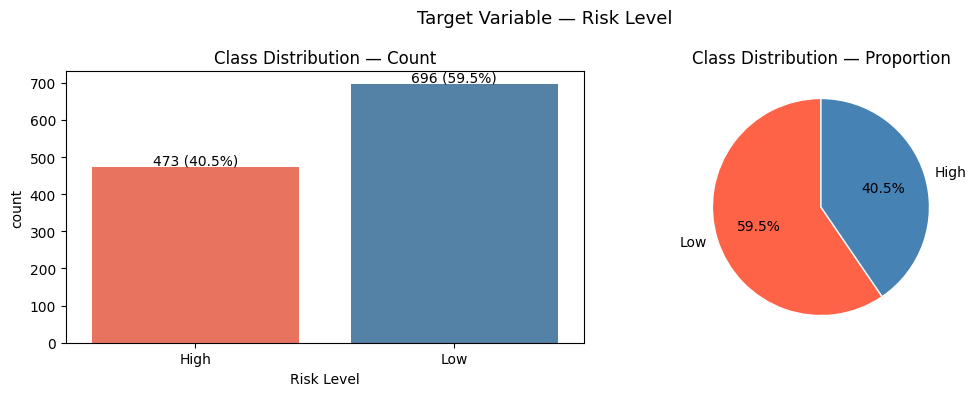

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Countplot
sns.countplot(data=df_clean, x="Risk Level", ax=axes[0],
              order=["High", "Low"],
              palette={"High": "tomato", "Low": "steelblue"})
axes[0].set_title("Class Distribution — Count")
for p in axes[0].patches:
    axes[0].annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df_clean)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

# Pie chart
target_counts = df_clean["Risk Level"].value_counts()
axes[1].pie(target_counts, labels=target_counts.index,
            autopct="%1.1f%%", colors=["tomato", "steelblue"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Distribution — Proportion")

plt.suptitle("Target Variable — Risk Level", fontsize=13)
plt.tight_layout()
plt.show()

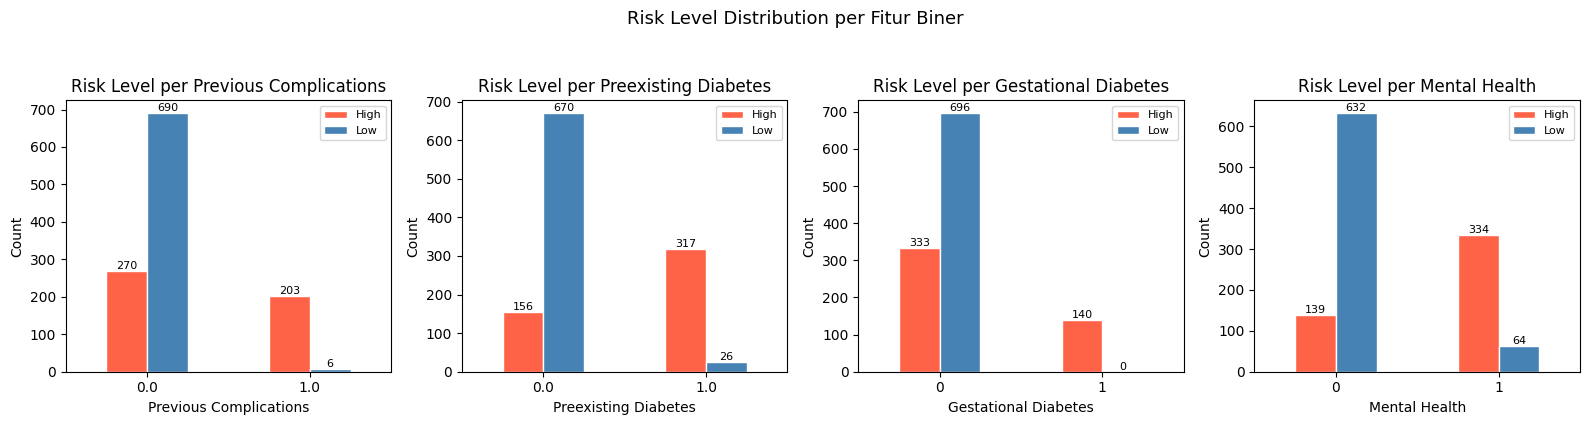

In [66]:
fig, axes = plt.subplots(1, len(binary_cols), figsize=(len(binary_cols) * 4, 4))
if len(binary_cols) == 1:
    axes = [axes]

for i, col in enumerate(binary_cols):
    ct = pd.crosstab(df_clean[col], df_clean["Risk Level"])
    ct.plot(kind="bar", ax=axes[i],
            color=["tomato", "steelblue"], edgecolor="white")
    axes[i].set_title(f"Risk Level per {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(loc="upper right", fontsize=8)
    for p in axes[i].patches:
        axes[i].annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=8
        )

plt.suptitle("Risk Level Distribution per Fitur Biner", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()